---
title: Performing EDA on Webscraped Data
author: Danyal Malik, Murtaza Ur Rehman, Daanish Uddin Khan, Noor Ul Hassan, Raiyaan Junaid
date: '2023-11-25'
categories:
  - code
format:
  html:
    code-fold: true
    code-tools: true
---

## Introduction

The dataset we will be working with is a webscraped dataset from Daraz.pk, a Pakistani E-commerce website. It contains 2444 products, each with 18 features. These will be described in further detail in the rest of the article.

## Section 1: Dataset Description and Cleaning

In this section, we will clean the dataset column by column. This will also give an overview of each column in the process. We will then describe any remaining columns at the end.

### Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("dark_background")

### Extracting Data

First, we extract data from the 5 separate csv files and concatenate it into one dataframe. As all the data was collected by the same process, we will clean it together and analyse each feature while doing so, in order to iteratively fix any errors we find in the dataset.

Note: We voluntarily leave some null values in during this section, as not all products had all information available, and the rows can still be useful for analysis later on even with null values (eg if we focus on two features at a time).

In [2]:
groceriesDF = pd.read_csv('groceries/data.csv')
healthandbeautyDF = pd.read_csv('health-and-beauty/data.csv')
homeappliancesDF = pd.read_csv('home-appliances/data.csv')
mobilesandtabletsDF = pd.read_csv('mobiles-and-tablets/data.csv')
sportsandoutdoorsDF = pd.read_csv('sports-and-outdoors/data.csv')

df = pd.concat([groceriesDF, healthandbeautyDF, homeappliancesDF, mobilesandtabletsDF, sportsandoutdoorsDF], axis=0, ignore_index=True)
df.head(5)

,Name,Category,Daraz Mall,url,Original Price,Discounted Price,Rating,Reviews,Seller,Seller Rating,Ship on Time,Chat Response Time,Warranty,Return Time,Delivery Charges,Brand,Answered Questions,SFO
0,Daal Moong/Mong - 1Kg (Premium Grains) - Zeest,"Groceries, Canned, Dry & Packaged Foods, Grain...",True,https://www.daraz.pk/products/daal-moongmong-1...,395,319,4.5,22,Zeest,92%,100%,88%,No warranty,No Return,Rs. 158,Zeest,NaN,False
1,Daal Masoor/Masur - 1Kg (Premium Grains) - Zeest,"Groceries, Canned, Dry & Packaged Foods, Grain...",True,https://www.daraz.pk/products/daal-masoormasur...,479,399,4.4,14,Zeest,92%,100%,88%,No warranty,No Return,Rs. 158,Zeest,NaN,False
2,Chia Seeds 500 g (Organic and Original 500 gra...,"Groceries, Canned, Dry & Packaged Foods, Grain...",False,https://www.daraz.pk/products/500-500-i4317113...,"1,200","1,099",5.0,10,Nuts & Snax,89%,100%,100%,No warranty,No Return,Free,No Brand,NaN,False
3,Moisture Absorber Dehumidifier Desicant 200 gr...,"Groceries, Laundry & Household, AirCare, Dehum...",False,https://www.daraz.pk/products/moisture-absorbe...,"1,000",599,5.0,2,Super Shop..,92%,100%,98%,No warranty,No Return,Free,No Brand,NaN,False
4,Barg e Sanober Powder (50GM),"Groceries, Canned, Dry & Packaged Foods, Grain...",False,https://www.daraz.pk/products/50-i432512130-s2...,600,500,5.0,1,Super pansar store,86%,100%,76%,No warranty,No Return,Rs. 119,Generic,NaN,False


### Setting Datatypes

Initially, we choose to set most of the features' datatypes to string, as this will allow us to use string methods to process the entries. (For example, removing percentage signs so we can later convert the column to int)

In [5]:
df['Name'] = df['Name'].astype(str)
df['Category'] = df['Category'].astype(str)
df['url'] = df['url'].astype(str)
df['Original Price'] = df['Original Price'].astype(str)
df['Discounted Price'] = df['Discounted Price'].astype(str)
df['Reviews'] = df['Reviews'].astype(str)
df['Seller Rating'] = df['Seller Rating'].astype(str)
df['Ship on Time'] = df['Ship on Time'].astype(str)
df['Chat Response Time'] = df['Chat Response Time'].astype(str)
df['Warranty'] = df['Warranty'].astype(str)
df['Return Time'] = df['Return Time'].astype(str)
df['Delivery Charges'] = df['Delivery Charges'].astype(str)
df['Brand'] = df['Brand'].astype(str)
df['Answered Questions'] = df['Answered Questions'].astype(str)

display(df.dtypes)

Name                   object
Category               object
Daraz Mall               bool
url                    object
Original Price         object
Discounted Price       object
Rating                float64
Reviews                object
Seller                 object
Seller Rating          object
Ship on Time           object
Chat Response Time     object
Warranty               object
Return Time            object
Delivery Charges       object
Brand                  object
Answered Questions     object
SFO                      bool
dtype: object

### Processing the `Price` Columns

These columns are "Original Price" and "Discounted Price". For each item, the original price is shown. For items with a discount, the Discounted Price is also stored, otherwise it is nan (initially).

We replace the `nan` values in "Discounted Price" with the corresponding Original Price

This will allow for easier processing as these values will not be ignored later on.

In [6]:
nan_indices = df['Discounted Price'] == 'nan'
df.loc[nan_indices, 'Discounted Price'] = df.loc[nan_indices, 'Original Price']

We then convert both "Original Price" and "Discounted Price" to int by removing the commas

In [7]:
df["Original Price"] = df["Original Price"].str.replace(",", "")
df["Discounted Price"] = df["Discounted Price"].str.replace(",", "")

df["Original Price"] = df["Original Price"].astype(int)
df["Discounted Price"] = df["Discounted Price"].astype(int)

print(f"\nChecking for NaN values in Discounted Price: {len(df[df['Discounted Price'] == 'nan'])}")



Checking for NaN values in Discounted Price: 0


For further analysis later on, we can define another column indicating whether there was a discount on the item

In [8]:
df["Discount"] = True
df.loc[nan_indices, "Discount"] = False

Finally, we view the statistics and some sample points to ensure everything is in order

In [9]:
print("\nSampling 5 points from each category to see if Discount column is working correctly: ")
display(df.loc[nan_indices, ['Original Price', 'Discounted Price', "Discount"]].sample(5))
display(df.loc[~nan_indices, ['Original Price', 'Discounted Price', "Discount"]].sample(5))

print("Statistics for Price")
display(df[["Original Price", "Discounted Price"]].describe().loc[["mean", "std", "min", "max"]])
display(df[["Original Price", "Discounted Price", "Discount"]].dtypes)


Sampling 5 points from each category to see if Discount column is working correctly: 


,Original Price,Discounted Price,Discount
1318,1648,1648,False
61,100,100,False
468,850,850,False
471,8000,8000,False
474,429,429,False


,Original Price,Discounted Price,Discount
2001,4599,3314,True
1349,5000,2199,True
111,199,150,True
2246,1200,550,True
722,1232,540,True


Statistics for Price


,Original Price,Discounted Price
mean,1662.021277,1258.316285
std,4119.102631,3554.110706
min,35.000000,21.000000
max,80500.000000,74999.000000


Original Price      int32
Discounted Price    int32
Discount             bool
dtype: object

### Processing `Reviews` Column

This column represents the number of reviews for each product.

We convert the column to int

To do this, we replace "No" entries in the Reviews column with 0

In [10]:
df.loc[df['Reviews'] == 'No', 'Reviews'] = '0'
df['Reviews'] = df['Reviews'].astype(int)

Then, we analyse the statistics to verify everything is working

In [11]:
print("Reviews Statistics")
display(df[["Reviews"]].describe().loc[["mean", "std", "min", "max"]])
print(f"Data Type: {df['Reviews'].dtype}")

Reviews Statistics


,Reviews
mean,83.092062
std,331.860118
min,0.000000
max,11505.000000


Data Type: int32


### Processing the `Seller Rating`, `Ship on Time` and `Chat Response Time` Columns

These columns contain the percentage value for each. The first represents positive seller rating percentage, the second: the percentage of time the order ships on time, and the third: the percentage of chat responses.

We convert each of these to int, and we purposely convert the entries with not enough data to NaN, so we can discard them from our calculations later on.

In [12]:
df.loc[df['Seller Rating'] == 'New Seller', 'Seller Rating'] = '-1'
df.loc[df['Seller Rating'] == 'Not enough data', 'Seller Rating'] = '-1'
df['Seller Rating'] = df['Seller Rating'].str.replace('%', '')
df['Seller Rating'] = df['Seller Rating'].astype(int)
df['Seller Rating'] = df['Seller Rating'] / 100
df.loc[df['Seller Rating'] < 0, 'Seller Rating'] = pd.NA

In [13]:
df.loc[df['Ship on Time'] == 'Not enough data', 'Ship on Time'] = '-1'
df['Ship on Time'] = df['Ship on Time'].str.replace('%', '')
df['Ship on Time'] = df['Ship on Time'].astype(int)
df['Ship on Time'] = df['Ship on Time'] / 100
df.loc[df['Ship on Time'] < 0, 'Ship on Time'] = pd.NA

In [14]:
df.loc[df['Chat Response Time'] == 'Not enough data', 'Chat Response Time'] = '-1'
df.loc[df['Chat Response Time'] == 'nan', 'Chat Response Time'] = '-1'
df['Chat Response Time'] = df['Chat Response Time'].str.replace('%', '')
df['Chat Response Time'] = df['Chat Response Time'].astype(int)
df['Chat Response Time'] = df['Chat Response Time'] / 100
df.loc[df['Chat Response Time'] < 0, 'Chat Response Time'] = pd.NA

Fixing the name of `Chat Response Time` by changing it to `Chat Response Rate`

In [15]:
df = df.rename(columns={"Chat Response Time":"Chat Response Rate"})

Viewing statistics to ensure everything is in order

In [16]:
print("Statistics")
display(df[["Seller Rating", "Ship on Time", "Chat Response Rate"]].describe().loc[["mean", "std", "min", "max"]])

Statistics


,Seller Rating,Ship on Time,Chat Response Rate
mean,0.828564,1.0,0.933602
std,0.111744,0.0,0.107626
min,0.330000,1.0,0.300000
max,1.000000,1.0,1.000000


We can see that the ship on time column has either not been scraped properly or there is some other issue, as all the values being 100% does not make any sense. So we will remove it.

In [17]:
df = df.drop(columns=["Ship on Time"])
df.columns

Index(['Name', 'Category', 'Daraz Mall', 'url', 'Original Price',
       'Discounted Price', 'Rating', 'Reviews', 'Seller', 'Seller Rating',
       'Chat Response Rate', 'Warranty', 'Return Time', 'Delivery Charges',
       'Brand', 'Answered Questions', 'SFO', 'Discount'],
      dtype='object')

### Processing the `Warranty` Column

This column contains the length of the period the warranty is valid for, but we need to parse this in order to convert it to a number value.

In [18]:
print("Values in Warranty Column: \n")
print(df["Warranty"].unique())

Values in Warranty Column: 

['No warranty' '1 Month Local seller warranty' '2 Months Brand Warranty'
 '1 Month Seller Warranty' '7 Months Brand Warranty'
 '8 Months Brand Warranty' '6 Months Seller Warranty'
 '1 Month Brand Warranty' '2 Months Local seller warranty'
 'Life Time Warranty Local seller warranty' '1 Month Non-local warranty'
 '10 Local seller warranty' '1 Year Brand Warranty'
 '1 Year Seller Warranty' '2 Years Seller Warranty'
 '2 Years Brand Warranty' '9 Months Seller Warranty'
 '3 Years Brand Warranty' '3 Months Brand Warranty'
 '4 Months Seller Warranty' '10 Years Brand Warranty'
 '3 Months Seller Warranty' '7 Months Seller Warranty' '7 Seller Warranty'
 '6 Months Brand Warranty' '5 Years Seller Warranty']


Converting the strings to easily interpretable strings for further processing

In [19]:
df.loc[df['Warranty'] == 'No warranty', 'Warranty'] = '0'
df.loc[df['Warranty'] == '1 Month Local seller warranty', 'Warranty'] = '1m'
df.loc[df['Warranty'] == '2 Months Brand Warranty', 'Warranty'] = '2m'
df.loc[df['Warranty'] == '1 Month Seller Warranty', 'Warranty'] = '1m'
df.loc[df['Warranty'] == '7 Months Brand Warranty', 'Warranty'] = '7m'
df.loc[df['Warranty'] == '8 Months Brand Warranty', 'Warranty'] = '8m'
df.loc[df['Warranty'] == '6 Months Seller Warranty', 'Warranty'] = '6m'
df.loc[df['Warranty'] == '1 Month Brand Warranty', 'Warranty'] = '1m'
df.loc[df['Warranty'] == '2 Months Local seller warranty', 'Warranty'] = '2m'
df.loc[df['Warranty'] == '1 Month Non-local warranty', 'Warranty'] = '1m'
df.loc[df['Warranty'] == '10 Local seller warranty', 'Warranty'] = '10m' # assuming 10 months
df.loc[df['Warranty'] == '1 Year Brand Warranty', 'Warranty'] = '1y'
df.loc[df['Warranty'] == '1 Year Seller Warranty', 'Warranty'] = '1y'
df.loc[df['Warranty'] == '2 Years Seller Warranty', 'Warranty'] = '2y'
df.loc[df['Warranty'] == '2 Years Brand Warranty', 'Warranty'] = '2y'
df.loc[df['Warranty'] == '9 Months Seller Warranty', 'Warranty'] = '9m'
df.loc[df['Warranty'] == '3 Years Brand Warranty', 'Warranty'] = '3y'
df.loc[df['Warranty'] == '3 Months Brand Warranty', 'Warranty'] = '3m'
df.loc[df['Warranty'] == '4 Months Seller Warranty', 'Warranty'] = '4m'
df.loc[df['Warranty'] == '10 Years Brand Warranty', 'Warranty'] = '10y'
df.loc[df['Warranty'] == '3 Months Seller Warranty', 'Warranty'] = '3m'
df.loc[df['Warranty'] == '7 Months Seller Warranty', 'Warranty'] = '7m'
df.loc[df['Warranty'] == '7 Seller Warranty', 'Warranty'] = '7y' # assuming 7 years
df.loc[df['Warranty'] == '6 Months Brand Warranty', 'Warranty'] = '6m'
df.loc[df['Warranty'] == '5 Years Seller Warranty', 'Warranty'] = '5y'
df.loc[df['Warranty'] == 'Life Time Warranty Local seller warranty', 'Warranty'] = 'inf'

Converting the column to int by representing them with the unit of months

Note: NaN in this column represents lifetime warranty, as we cannot include infinity in statistical analysis

In [20]:
warranty = pd.Series([0 for i in range(len(df))])
warranty[df["Warranty"] == 'inf'] = pd.NA

df["Warranty"] = df["Warranty"].str.replace("m", "")
rows_with_years = df["Warranty"].str.contains("y")
df["Warranty"] = df["Warranty"].str.replace("y", "")

warranty[df["Warranty"] != 'inf'] = df[df["Warranty"] != 'inf']["Warranty"].astype(int)
warranty[rows_with_years] = warranty[rows_with_years] * 12

df["Warranty"] = warranty

print("Statistics")
display(df[["Warranty"]].describe().loc[["mean", "std", "min", "max"]])

Statistics


,Warranty
mean,0.457412
std,4.619663
min,0.000000
max,120.000000


### Processing the `Return` Column

This column, similar to `Warranty`, represents the return policy, along with the period allowed.

Analysing unique values in the column

In [21]:
print("Values in Return Column")
print(df["Return Time"].unique())

Values in Return Column
['No Return']


We can see that this column was also not extracted properly, as there is only one type of value. So we drop it.

In [22]:
df = df.drop(columns=["Return Time"])
df.columns

Index(['Name', 'Category', 'Daraz Mall', 'url', 'Original Price',
       'Discounted Price', 'Rating', 'Reviews', 'Seller', 'Seller Rating',
       'Chat Response Rate', 'Warranty', 'Delivery Charges', 'Brand',
       'Answered Questions', 'SFO', 'Discount'],
      dtype='object')

### Processing the `Delivery Charges` and `Answered Questions` Column

These columns contains the additional charges for delivery of the product, and the number of customer questions answered by the seller under the product.

Convert the columns to int

In [23]:
df.loc[df['Delivery Charges'] == 'Free', 'Delivery Charges'] = '0'
df.loc[df['Delivery Charges'] == 'nan', 'Delivery Charges'] = '-1'
df['Delivery Charges'] = df['Delivery Charges'].str.replace('Rs. ', '')
df['Delivery Charges'] = df['Delivery Charges'].astype(int)
df.loc[df['Delivery Charges'] < 0, 'Delivery Charges'] = pd.NA


df.loc[df['Answered Questions'] == 'nan', 'Answered Questions'] = '0'
df['Answered Questions'] = df['Answered Questions'].astype(float)
df['Answered Questions'] = df['Answered Questions'].astype(int)

Checking statistics

In [24]:
display(df[["Delivery Charges", "Answered Questions"]].describe().loc[["mean", "std", "min", "max"]])

,Delivery Charges,Answered Questions
mean,57.366372,19.241408
std,73.949502,72.164159
min,0.000000,0.000000
max,879.000000,1855.000000


### Some other odd jobs

Removing `SFO` Column

The column represents whether the product is shipped from overseas. But, all the entries are false, so there was some issue when collecting the data. Hence, we remove this column too.

In [25]:
print(df["SFO"].unique())

[False]


In [26]:
df = df.drop(columns=["SFO"])
df.columns

Index(['Name', 'Category', 'Daraz Mall', 'url', 'Original Price',
       'Discounted Price', 'Rating', 'Reviews', 'Seller', 'Seller Rating',
       'Chat Response Rate', 'Warranty', 'Delivery Charges', 'Brand',
       'Answered Questions', 'Discount'],
      dtype='object')

Fixing Category Formatting

This column represents the category along with all the subcategories of the product

In [27]:
print("Before")
print(df["Name"].head(1).item())
print(df["Category"].head(1).item())

for index, row in df.iterrows():
    df.at[index, 'Category'] = row['Category'].replace(", "+row['Name'], '').strip()

print("After")
print(df["Name"].head(1).item())
print(df["Category"].head(1).item())

Before
Daal Moong/Mong - 1Kg (Premium Grains) - Zeest
Groceries, Canned, Dry & Packaged Foods, Grains, Beans & Pulses, Lentils, Daal Moong/Mong - 1Kg (Premium Grains) - Zeest
After
Daal Moong/Mong - 1Kg (Premium Grains) - Zeest
Groceries, Canned, Dry & Packaged Foods, Grains, Beans & Pulses, Lentils


### Final Analysis of the Dataset

In [28]:
df.describe(include="all")

,Name,Category,Daraz Mall,url,Original Price,Discounted Price,Rating,Reviews,Seller,Seller Rating,Chat Response Rate,Warranty,Delivery Charges,Brand,Answered Questions,Discount
count,2444,2444,2444,2444,2444.000000,2444.000000,2444.000000,2444.000000,2444,2096.000000,2285.000000,2442.000000,2260.000000,2444,2444.000000,2444
unique,1850,208,2,2444,NaN,NaN,NaN,NaN,1229,NaN,NaN,NaN,NaN,253,NaN,2
top,Large Capacity Makeup Pouch Multi function Pur...,"Mobiles & Tablets, Mobile Accessories, Screen ...",False,https://www.daraz.pk/products/daal-moongmong-1...,NaN,NaN,NaN,NaN,HEALTHEE U,NaN,NaN,NaN,NaN,No Brand,NaN,True
freq,8,239,2121,1,NaN,NaN,NaN,NaN,44,NaN,NaN,NaN,NaN,1802,NaN,1868
mean,NaN,NaN,NaN,NaN,1662.021277,1258.316285,3.362889,83.092062,NaN,0.828564,0.933602,0.457412,57.366372,NaN,19.241408,NaN
std,NaN,NaN,NaN,NaN,4119.102631,3554.110706,2.015331,331.860118,NaN,0.111744,0.107626,4.619663,73.949502,NaN,72.164159,NaN
min,NaN,NaN,NaN,NaN,35.000000,21.000000,0.000000,0.000000,NaN,0.330000,0.300000,0.000000,0.000000,NaN,0.000000,NaN
25%,NaN,NaN,NaN,NaN,399.000000,260.750000,0.000000,0.000000,NaN,0.800000,0.910000,0.000000,0.000000,NaN,0.000000,NaN
50%,NaN,NaN,NaN,NaN,700.000000,499.000000,4.500000,9.000000,NaN,0.850000,0.980000,0.000000,0.000000,NaN,1.000000,NaN
75%,NaN,NaN,NaN,NaN,1499.000000,1000.000000,4.800000,58.000000,NaN,0.890000,1.000000,0.000000,119.000000,NaN,13.000000,NaN


Remaining Columns Described

In [29]:
print(df.dtypes)

Name                   object
Category               object
Daraz Mall               bool
url                    object
Original Price          int32
Discounted Price        int32
Rating                float64
Reviews                 int32
Seller                 object
Seller Rating         float64
Chat Response Rate    float64
Warranty              float64
Delivery Charges      float64
Brand                  object
Answered Questions      int32
Discount                 bool
dtype: object


Daraz Mall: Boolean dtype; Indicates whether the item is on Daraz Mall.

url: String dtype; unique url for each product

Rating: Float dtype; 0 to 5 star average product rating

Seller: String dtype; the name of the seller

Brand: String dtype; the name of the brand

<div style="color:white;">.</div>

Finally, we save the processed dataset

In [30]:
df.to_csv(path_or_buf="final_dataset.csv")
data = df

## Section 2: Visualisation

### Univariate Analysis

#### Functions To Display Graphs

In [31]:

# Displaying The Plots
def price_histograms(data, threshold, flag, col):
    price = data[col]

    title = ""

    plotting = None

    if flag == 1:
        plotting = price[price < threshold]
        if col == "Discounted Price":
            title = "Distribution of Discounted Prices Less Than Rs 5000"
        else:
            title = "Distribution of Product Prices Less Than Rs 5000"
    elif flag == 0:
        plotting = price[price >= threshold]
        if col == "Discounted Price":
            title = "Distribution of Discounted Prices Greater Than Rs 5000"
        else:
            title = "Distribution of Product Prices Greater Than Rs 5000"
    # plt.hist(original_price_half1, bins=30)

    plt.hist(plotting, bins=30, edgecolor='black')
    plt.ylabel("Frequency of Price")
    plt.xlabel("Price (Rs)")
    plt.title(title)
    plt.tight_layout()

def histograms(plotting, col):
    plt.hist(plotting, bins=30, edgecolor='black')
    plt.ylabel(f"Frequency of {col}")
    plt.xlabel(col)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()

def boxplot(plotting, col):
    plt.boxplot(plotting)
    plt.title(f"Boxplot of {col}")

def kde(plotting, col):
    sns.kdeplot(plotting, fill=True)
    plt.title(f"KDE of {col}")

#### Data Visualisation
Each numerical column is visualised using histograms, box plots and Kernel Density Estimation plots.

For the column, 'Original Price', the values have been split and visualised using two separate plots for each, to account for the fact that the bulk of the data lies towards the lower values but there are some outliers towards the extreme end. 

#### Original Price

These plots visualise the Original Price values less than the defined threshold (5000)

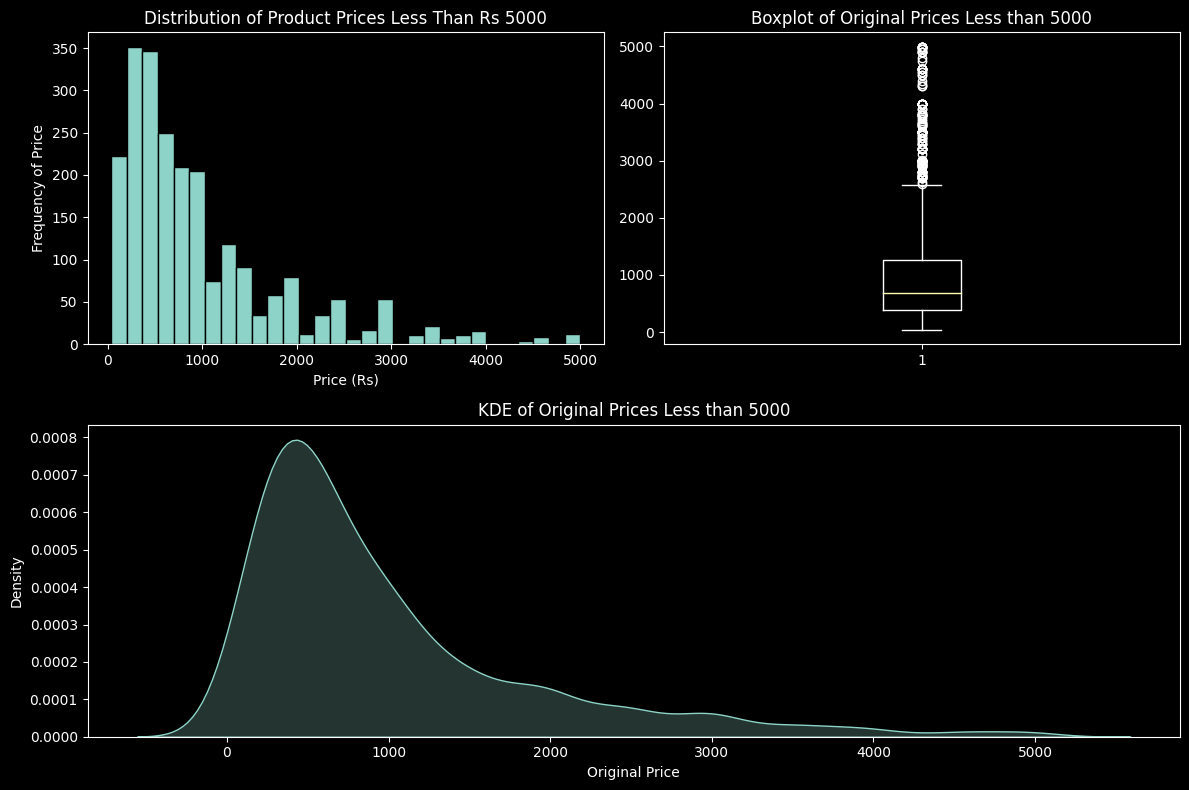

In [32]:

# Splitting Original Price on Threshold 5000 to better display distributions
# Histogram
plt.figure(figsize=(12, 8))
plt.subplot(221)
price_histograms(data, 5000, 1, "Original Price")

price = data['Original Price']
plotting = price[price < 5000]

# Boxplot
plt.subplot(222)
boxplot(plotting, "Original Price")
plt.title("Boxplot of Original Prices Less than 5000")

# Null Check
null = plotting.isnull()

if null.any():
    print("Null values present in column")

# KDE
plt.subplot(212)
kde(plotting, "Original Prices Less than 5000")

# Ensuring No Overlap
plt.tight_layout()
plt.show()

These plots visualise the Original Price values greater than or equal to the defined threshold (5000)

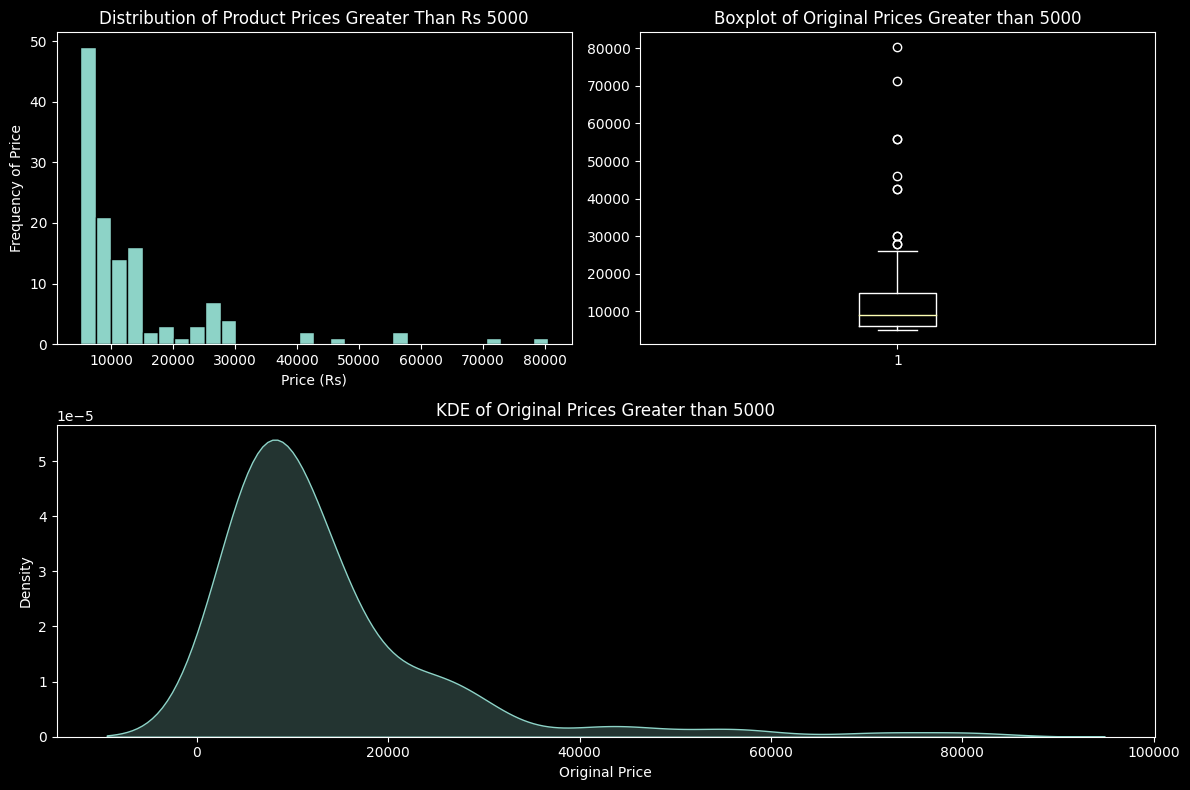

In [33]:

# Plotting Histogram
plt.figure(figsize=(12, 8))
plt.subplot(221)
price_histograms(data, 5000, 0, "Original Price")

# Plotting Box Plots
plt.subplot(222)
plotting = price[price >= 5000]
boxplot(plotting, "Original Price")
plt.title("Boxplot of Original Prices Greater than 5000")

# Null Check
null = plotting.isnull()

if null.any():
    print("Null values present in column")

# Plotting KDE
plt.subplot(212)
kde(plotting, "Original Prices Greater than 5000")

# Ensuring No Overlap In Graphs
plt.tight_layout()
plt.show()

#### Discounted Prices

These plots visualise the Discounted Price values less than the defined threshold (5000)

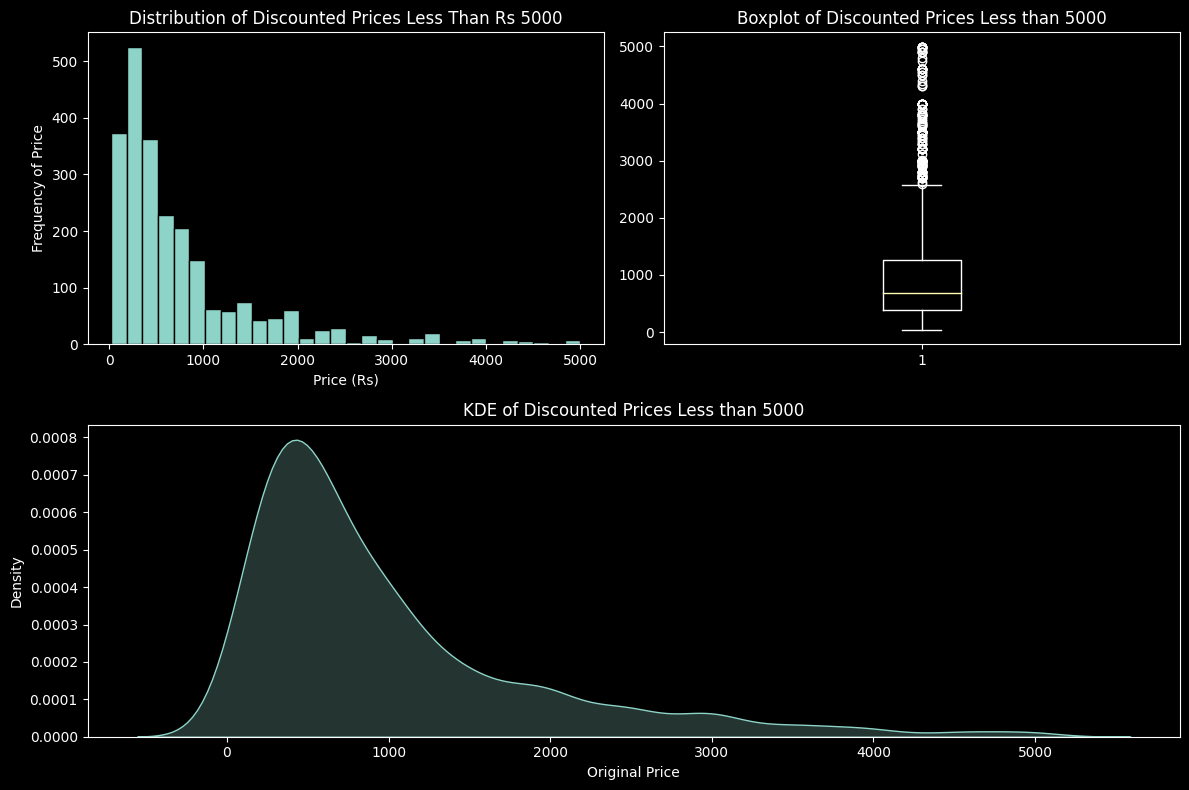

In [34]:

# Splitting Discounted Price on Threshold 5000 to better display distribution
# Plotting Histograms
plt.figure(figsize=(12, 8))
plt.subplot(221)
price_histograms(data, 5000, 1, "Discounted Price")


# Plotting Boxplots
plt.subplot(222)
plotting = price[price < 5000]
boxplot(plotting, "Discounted Price")
plt.title("Boxplot of Discounted Prices Less than 5000")

# Null Check
null = plotting.isnull()

if null.any():
    print("Null values present in column")

# Plotting KDE
plt.subplot(212)
kde(plotting, "Discounted Prices Less than 5000")

# Ensuring No Overlaps in Graphs
plt.tight_layout()
plt.show()

These plots visualise the Original Price values greater than or equal to the defined threshold (5000)

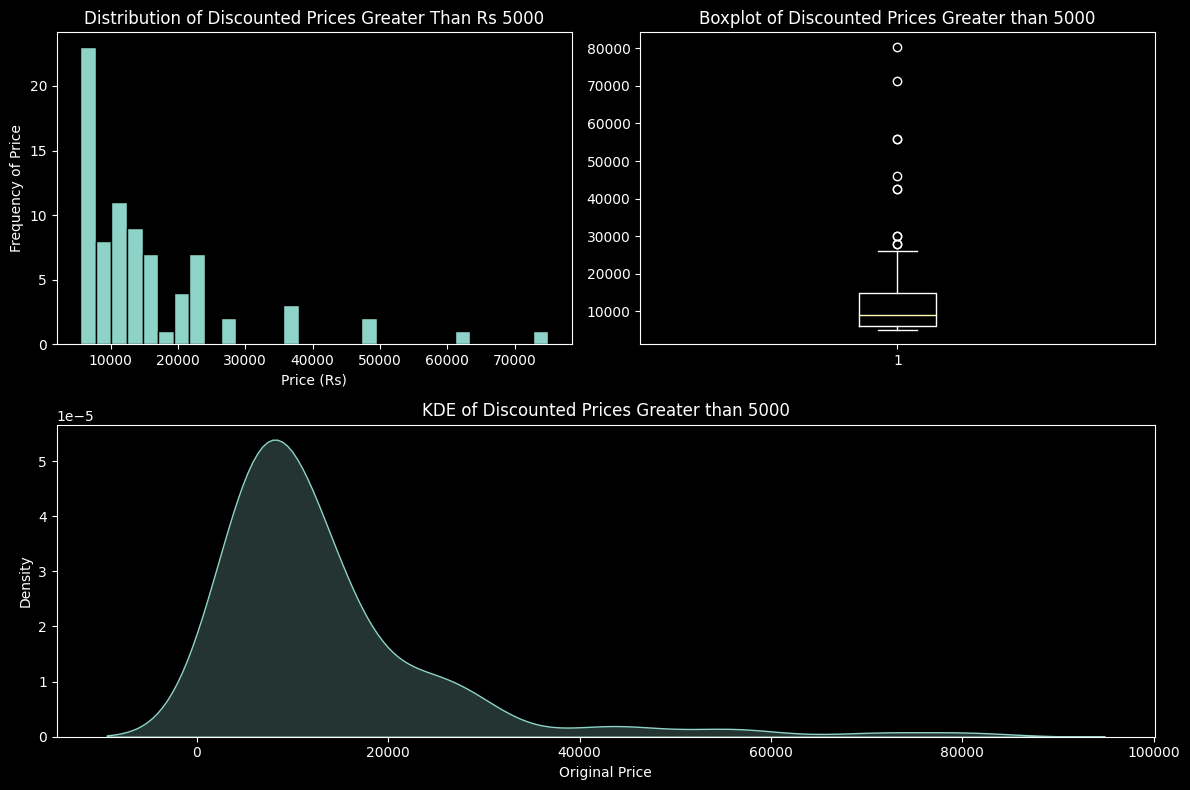

In [35]:

# Plotting Histogram
plt.figure(figsize=(12, 8))
plt.subplot(221)
price_histograms(data, 5000, 0, "Discounted Price")

# Plotting Boxplot
plt.subplot(222)
plotting = price[price >= 5000]
boxplot(plotting, "Discounted Price")
plt.title("Boxplot of Discounted Prices Greater than 5000")

# KDE
plt.subplot(212)
kde(plotting, "Discounted Prices Greater than 5000")

# Null Check
null = plotting.isnull()

if null.any():
    print("Null values present in column")

# Ensuring No Overlap
plt.tight_layout()
plt.show()

#### Discount

These plots visualise the Difference between the Original Prices and discounted prices, giving us the distribution of the discounts given on each product

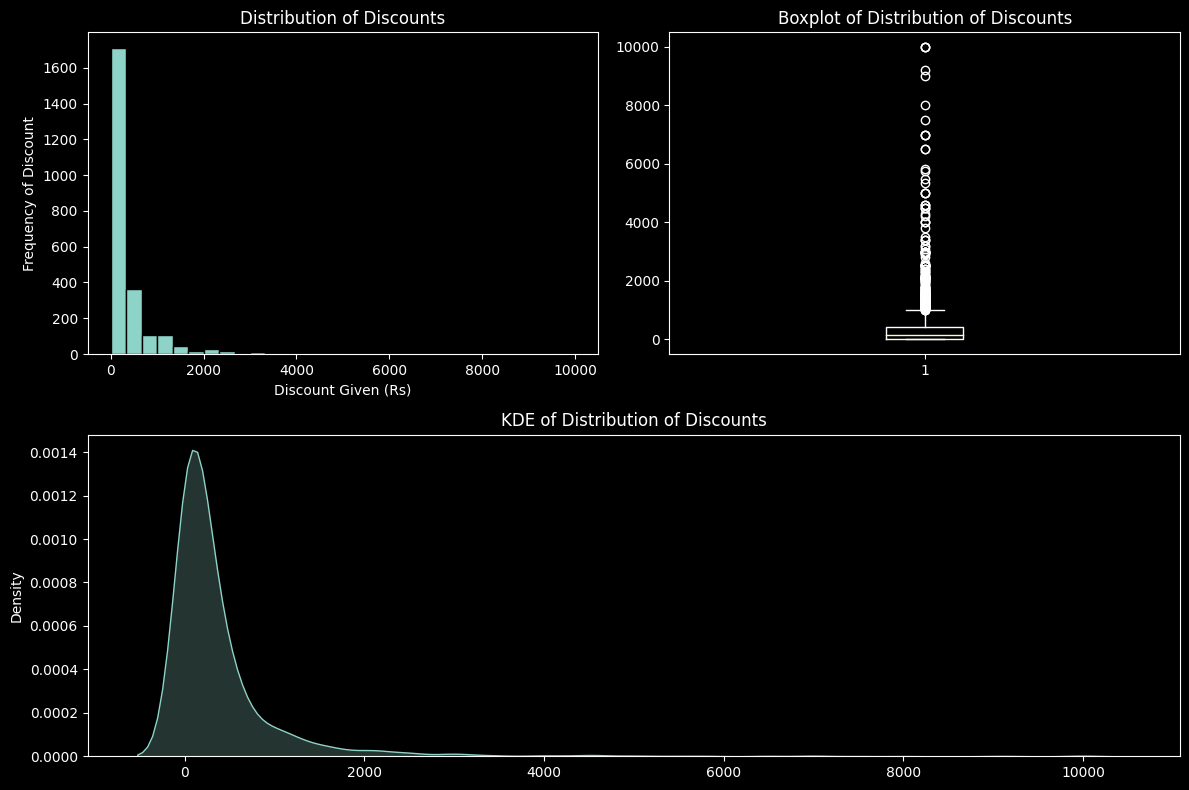

In [36]:

# Plotting The Distribution of Max Discounts
discounts = data["Original Price"] - data["Discounted Price"]

# Histogram
plt.figure(figsize=(12, 8))
plt.subplot(221)
plt.hist(discounts, bins=30, edgecolor='black')
plt.ylabel("Frequency of Discount")
plt.xlabel("Discount Given (Rs)")
plt.title("Distribution of Discounts")

# Boxplot
plt.subplot(222)
boxplot(discounts, "Distribution of Discounts")

# Null Check
null = discounts.isnull()

if null.any():
    print("Null values present in column")

# KDE
plt.subplot(212)
kde(discounts, "Distribution of Discounts")

# Ensuring No Overlap
plt.tight_layout()
plt.show()

#### Ratings

Visualisation of the distribution of rating shows that most of our ratings lie on extreme ends, a rating of zero or five. Further reinforced by the KDE shown below.

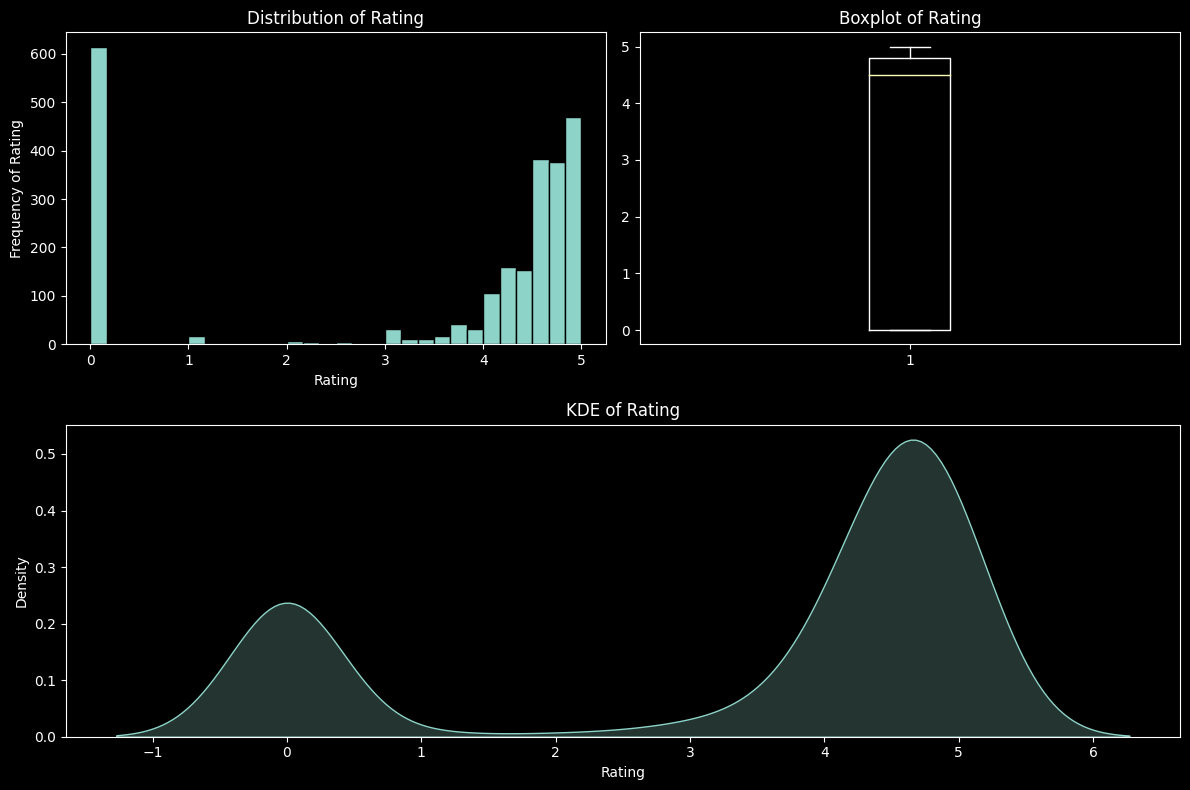

In [37]:

# Histogram
plt.figure(figsize=(12, 8))
plt.subplot(221)
data_plot = data["Rating"]
histograms(data_plot, "Rating")

# Boxplot
plt.subplot(222)
boxplot(data_plot, "Rating")

# Null Check
null = data_plot.isnull()

if null.any():
    print("Null values present in column")

# KDE
plt.subplot(212)
kde(data_plot, "Rating")

# Ensuring No Overlap
plt.tight_layout()
plt.show()

#### Number of Reviews

Number of Reviews lie mostly towards the lower extreme end with some outliers towards the highest extreme. So to be able to visualise the data better, it has been split on the threshold of 500.

The following plots display the visualisation of Number of Reviews which fall in the threshold below 500.

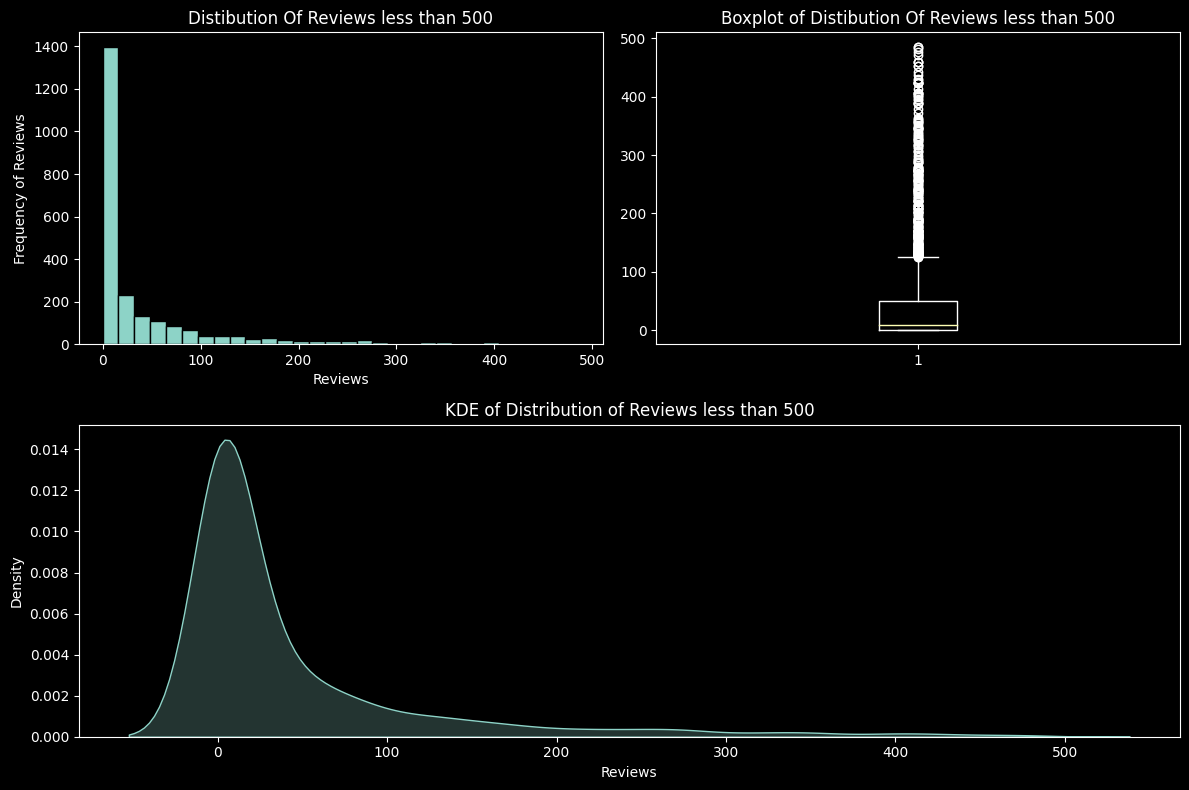

In [38]:

# reviews
# Histogram
plt.figure(figsize=(12, 8))
plt.subplot(221)
rev = data["Reviews"]
less = rev[rev < 500]
histograms(less, "Reviews")
plt.title("Distibution Of Reviews less than 500")

# Boxplot
plt.subplot(222)
boxplot(less, "Distibution Of Reviews less than 500")

# Null Check
null = less.isnull()

if null.any():
    print("Null values present in column")

# KDE
plt.subplot(212)
kde(less, "Distribution of Reviews less than 500")

# Ensuring No Overlap
plt.tight_layout()
plt.show()

The following plots display the visualisation of Number of Reviews which fall in the threshold above and equal to 500.

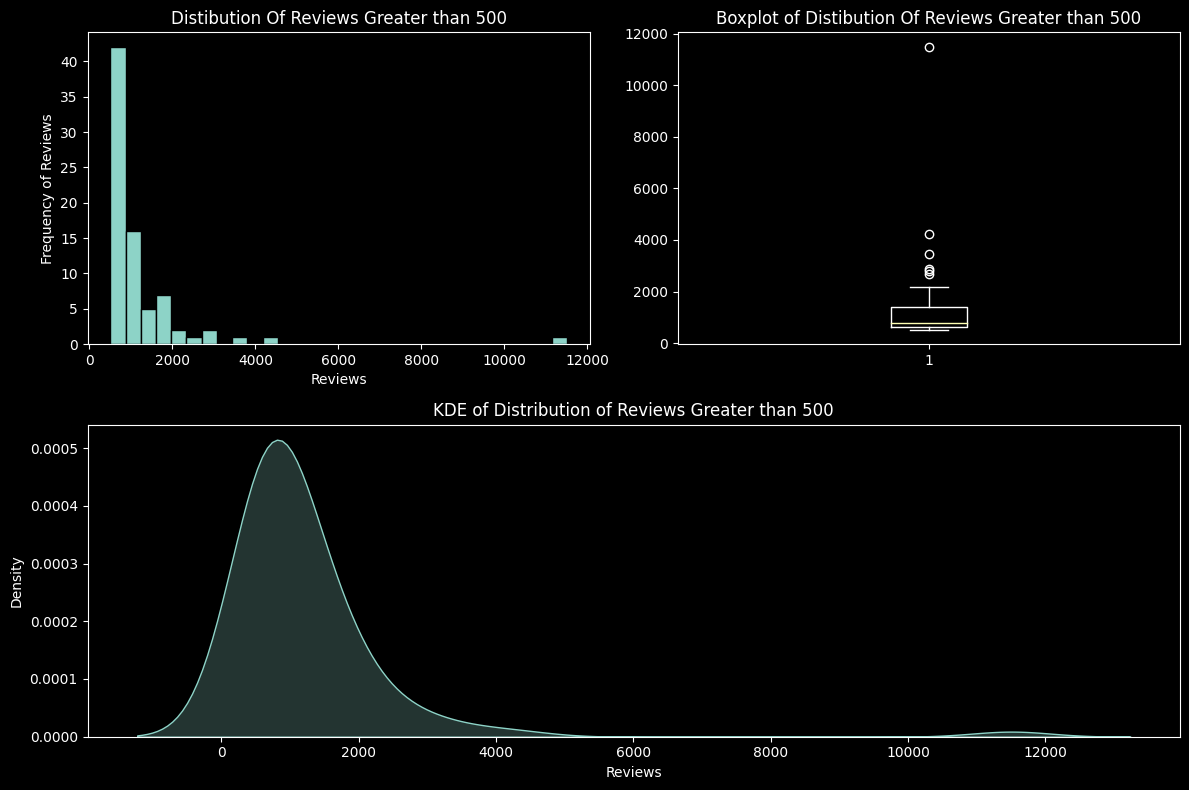

In [39]:

# Histogram
plt.figure(figsize=(12, 8))
plt.subplot(221)
rev = data["Reviews"]
more = rev[rev >= 500]
histograms(more, "Reviews")
plt.title("Distibution Of Reviews Greater than 500")

# Boxplot
plt.subplot(222)
boxplot(more, "Distibution Of Reviews Greater than 500")

# Null Check
null = more.isnull()

if null.any():
    print("Null values present in column")

# KDE
plt.subplot(212)
kde(more, "Distribution of Reviews Greater than 500")

# Ensuring No Overlap
plt.tight_layout()
plt.show()

#### Seller Rating

Visualisation of the Seller Rating shows that most sellers have a high rating as the bulk of the data is above 0.8.

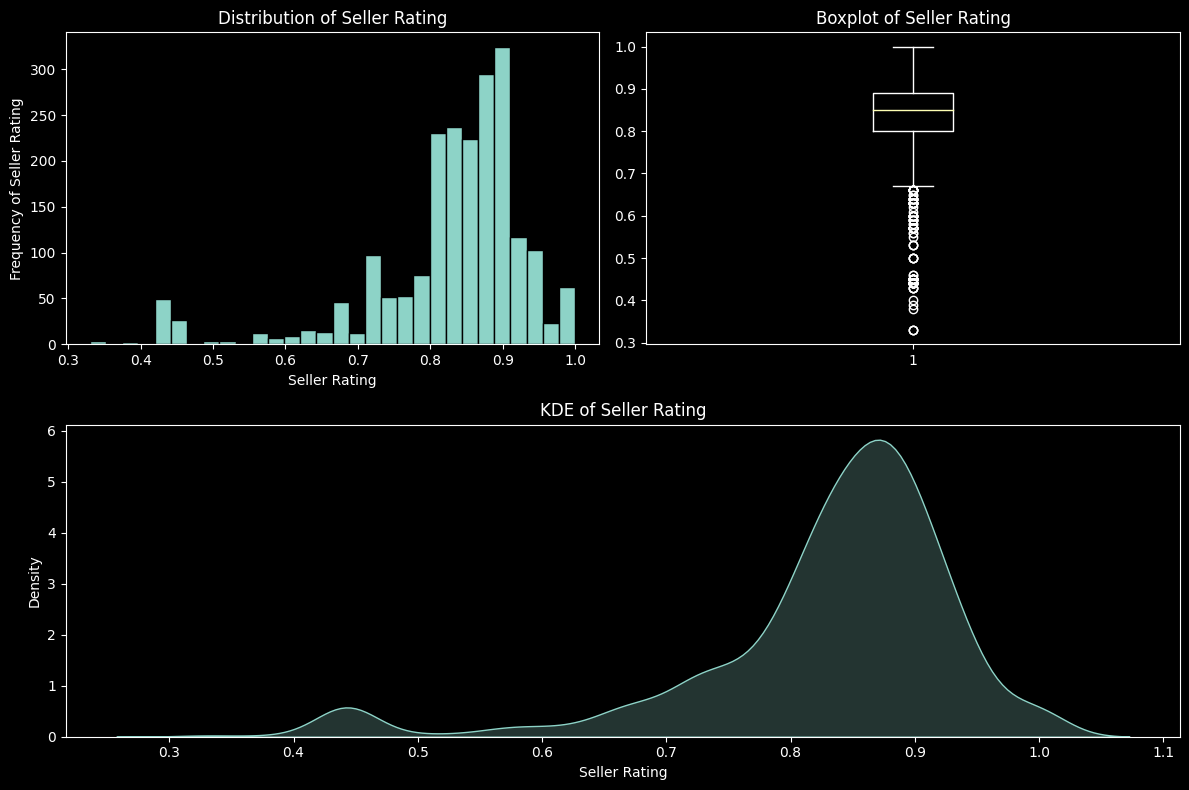

In [40]:

# Histogram
plt.figure(figsize=(12, 8))
plt.subplot(221)
sell = data["Seller Rating"]
histograms(sell, "Seller Rating")

null = sell.isnull()

# Null Check
if null.any():
    sell.dropna(inplace=True)

# Box plot
plt.subplot(222)
boxplot(sell, "Seller Rating")

# KDE
plt.subplot(212)
kde(sell, "Seller Rating")

# Ensuring No Overlap
plt.tight_layout()
plt.show()

#### Chat Response Rate

Chat Response Rate also lies towards the higher end of its range

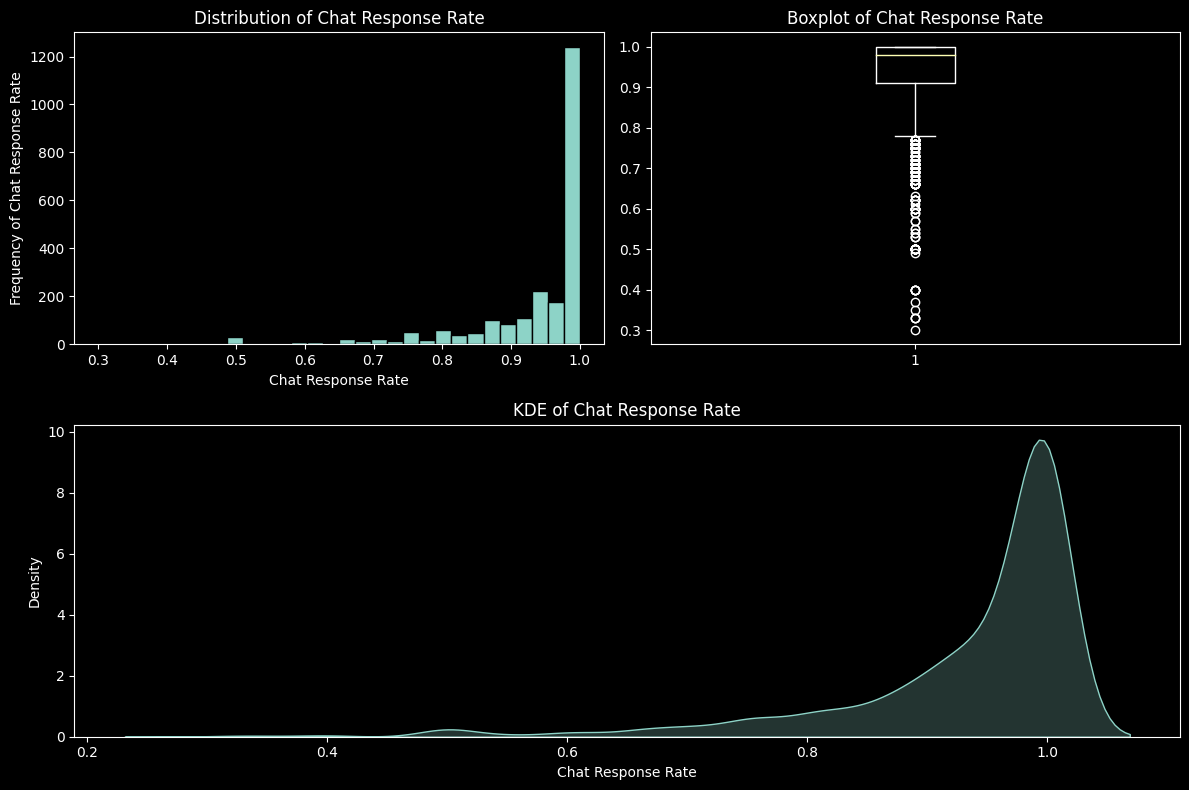

In [41]:

# Histogram
plt.figure(figsize=(12, 8))
plt.subplot(221)
sell = data["Chat Response Rate"]
histograms(sell, "Chat Response Rate")

# Null Check
if null.any():
    sell.dropna(inplace=True)

# Boxplot
plt.subplot(222)
boxplot(sell, "Chat Response Rate")

# KDE
plt.subplot(212)
kde(sell, "Chat Response Rate")

# Ensuring No Overlap
plt.tight_layout()
plt.show()

#### Warranty

Most of the warranty values were 0 as most of the products did not have warranties, and a few products which were outliers had warranty. The warranty is in months in the data. To display the data better in the graphs the warranty frequency values were log scaled.

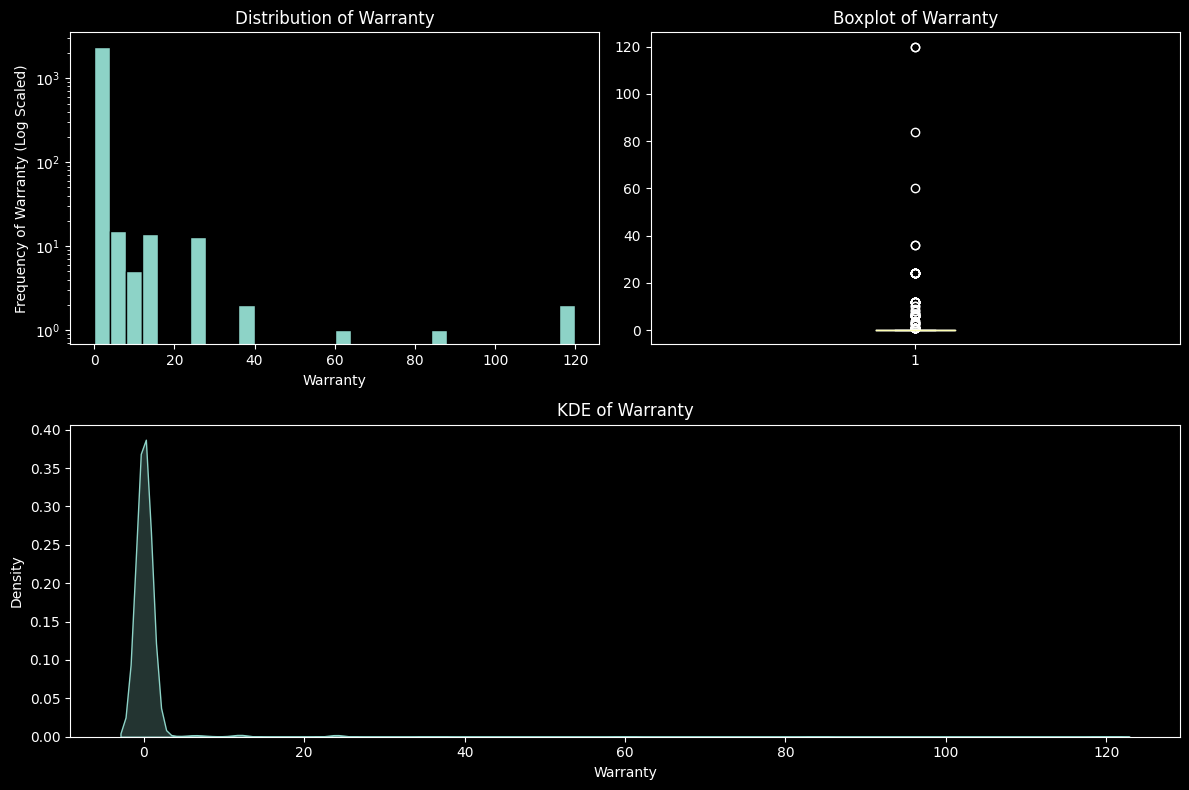

In [42]:
# Log Scale
# Histogram
plt.figure(figsize=(12, 8))
plt.subplot(221)
sell = data["Warranty"]
plt.yscale('log')
histograms(sell, "Warranty")
plt.ylabel("Frequency of Warranty (Log Scaled)")

# Null Check
if null.any():
    sell.dropna(inplace=True)

# Boxplot
plt.subplot(222)
boxplot(sell, "Warranty")

# KDE
plt.subplot(212)
kde(sell, "Warranty")

# Ensuring No Overlap
plt.tight_layout()
plt.show()

#### Delivery Charges

Most sellers did not take delivery charges and the ones who did not charge high amounts.

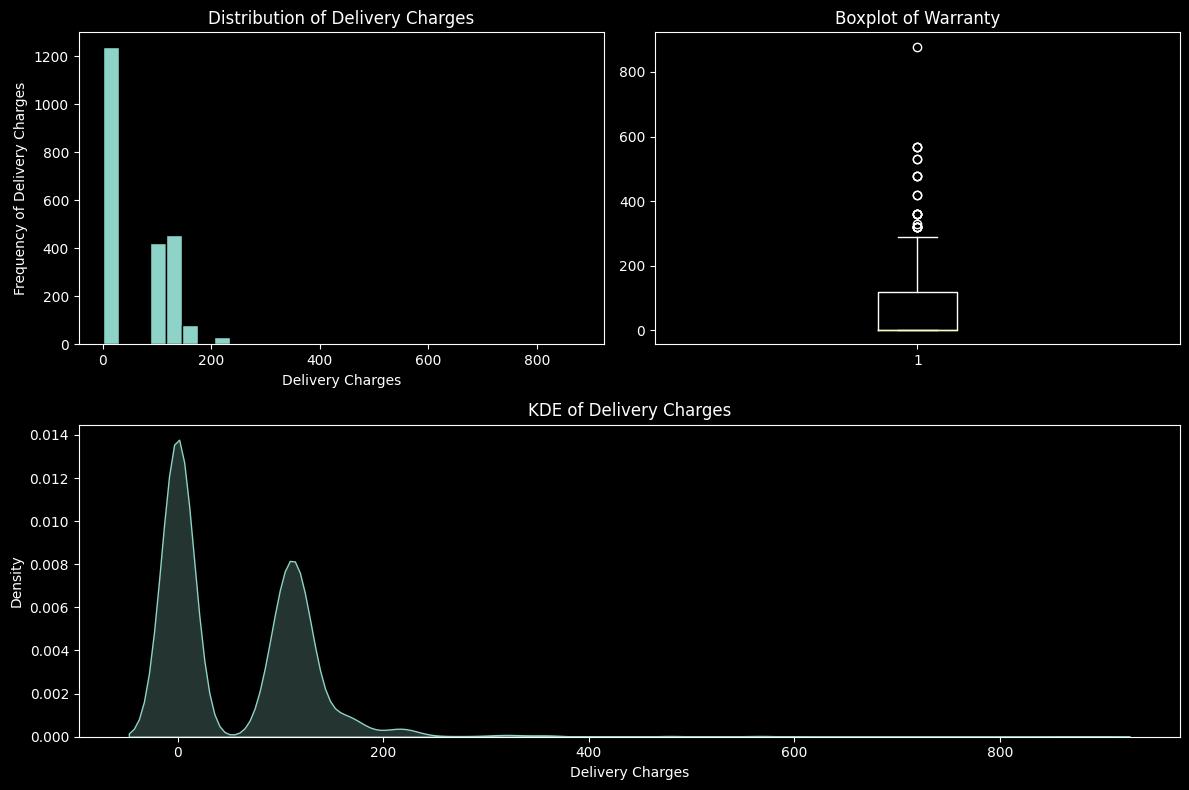

In [43]:

# Histogram
plt.figure(figsize=(12, 8))
plt.subplot(221)
sell = data["Delivery Charges"]
histograms(sell, "Delivery Charges")

# Null Check
if null.any():
    sell.dropna(inplace=True)

# Boxplot
plt.subplot(222)
boxplot(sell, "Warranty")

# KDE
plt.subplot(212)
kde(sell, "Delivery Charges")

# Ensuring No Overlap
plt.tight_layout()
plt.show()

#### Answered Questions
90% of the questions were left unanswered by the sellers as can be visualised below

While the bulk of the data is towards the left extreme of the data, their are still values that lie at the other extreme, so again we have split the visualisation into two parts where the first part displays the Answered questions less than a defined threshold, which is 200.

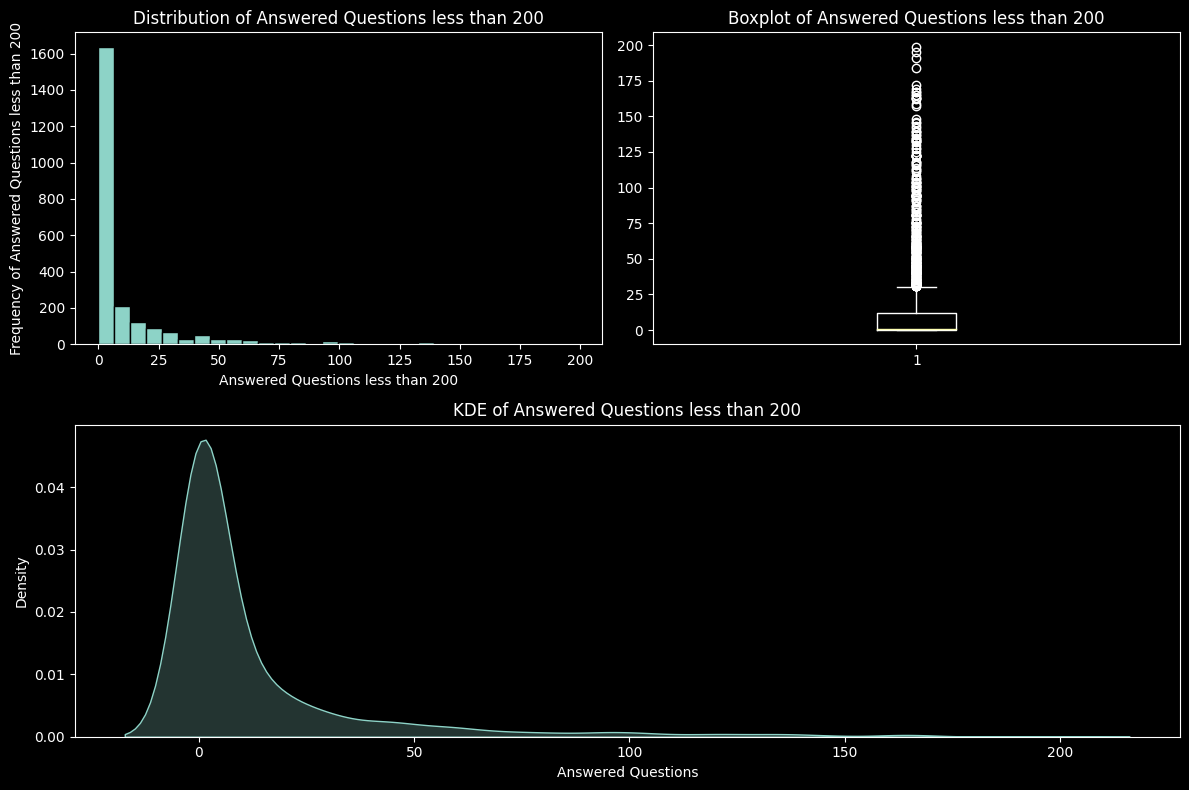

In [44]:

# Histograms
plt.figure(figsize=(12, 8))
plt.subplot(221)
sell = data["Answered Questions"]
sell_less = sell[sell < 200]
histograms(sell_less, "Answered Questions less than 200")

# Boxplot
plt.subplot(222)
boxplot(sell_less, "Answered Questions less than 200")

# Null Check
null = sell.isnull()

if null.any():
    print("Null values present in column")

# KDE
plt.subplot(212)
kde(sell_less, "Answered Questions less than 200")

# Enssuring No Overlap
plt.tight_layout()
plt.show()

The second part displays the Answered Questions that are greater than a defined threshold, which is 200.

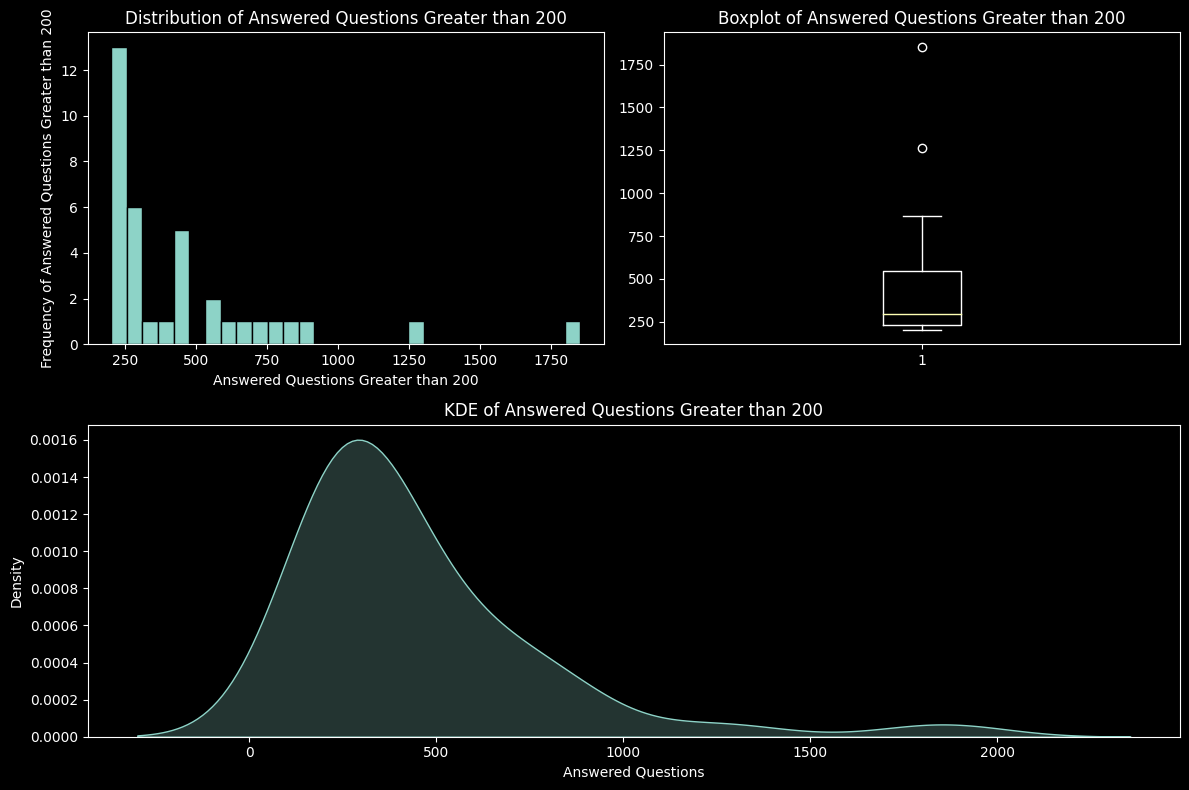

In [45]:

# Histograms
plt.figure(figsize=(12, 8))
plt.subplot(221)
sell = data["Answered Questions"]
sell_more = sell[sell >= 200]
histograms(sell_more, "Answered Questions Greater than 200")

# Boxplot
plt.subplot(222)
boxplot(sell_more, "Answered Questions Greater than 200")

# KDE
plt.subplot(212)
kde(sell_more, "Answered Questions Greater than 200")

# Ensuring No Overlap
plt.tight_layout()
plt.show()

#### Subcategories Visualised

We show the proportion of all subcategories in each category in the following section.

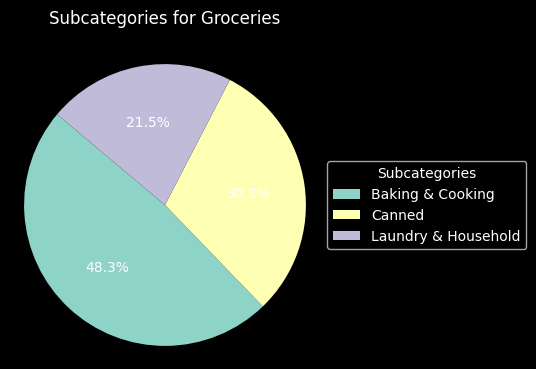

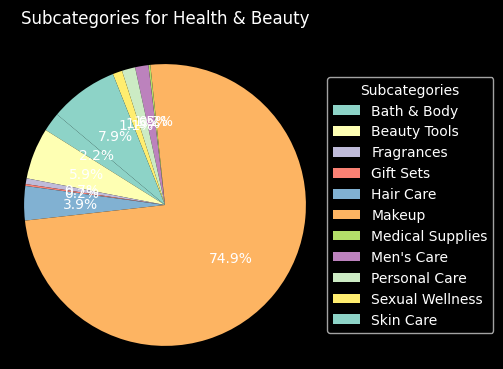

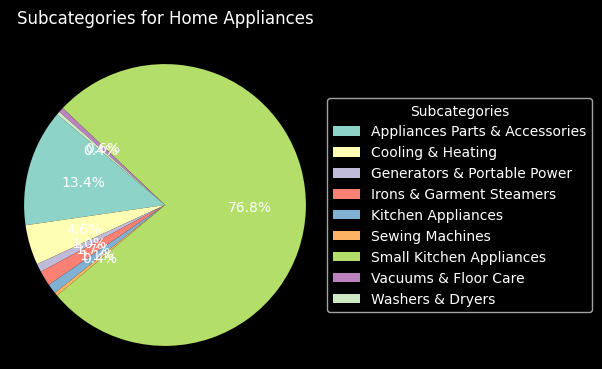

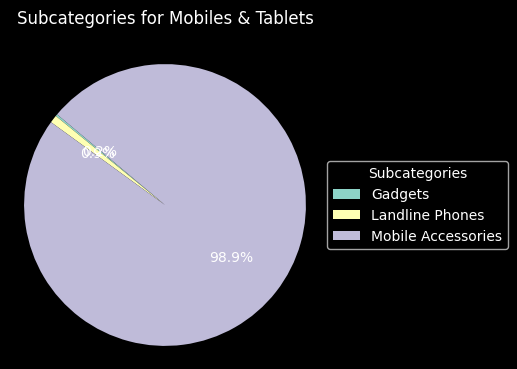

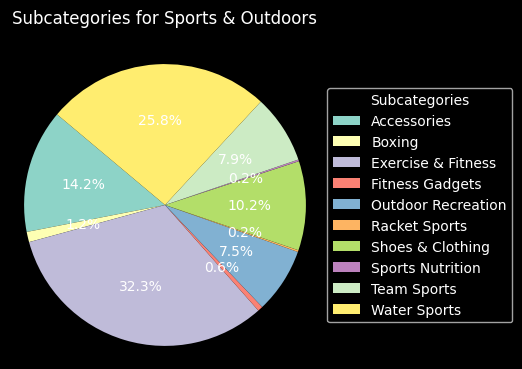

In [46]:
df['Main Category'] = df['Category'].apply(lambda x: x.split(',')[0].strip())
df['Subcategory'] = df['Category'].apply(lambda x: x.split(',')[1].strip())

grouped = df.groupby(['Main Category', 'Subcategory']).size().reset_index(name='Count')

main_categories = grouped['Main Category'].unique()

for category in main_categories:
    sub_data = grouped[grouped['Main Category'] == category]
    
    plt.figure(figsize=(4, 4))
    wedges, texts, autotexts = plt.pie(sub_data['Count'], labels=None, autopct='%1.1f%%', startangle=140)
    plt.title(f"Subcategories for {category}", pad=20)
    plt.axis('equal')  

    plt.legend(sub_data['Subcategory'], loc='center left', bbox_to_anchor=(1, 0.5), title='Subcategories')

    plt.show()


As we can see, all the column distributions seem to make sense, so we need not make any further changes to them. Our plots helped us understand theses distributions better, as described above, and also helped us ensure there are no big issues with the values.

### Multivariate Analysis

#### Pairplot

We visualise relationships between columns by using scatterplots for each pair

<Figure size 1200x1200 with 0 Axes>

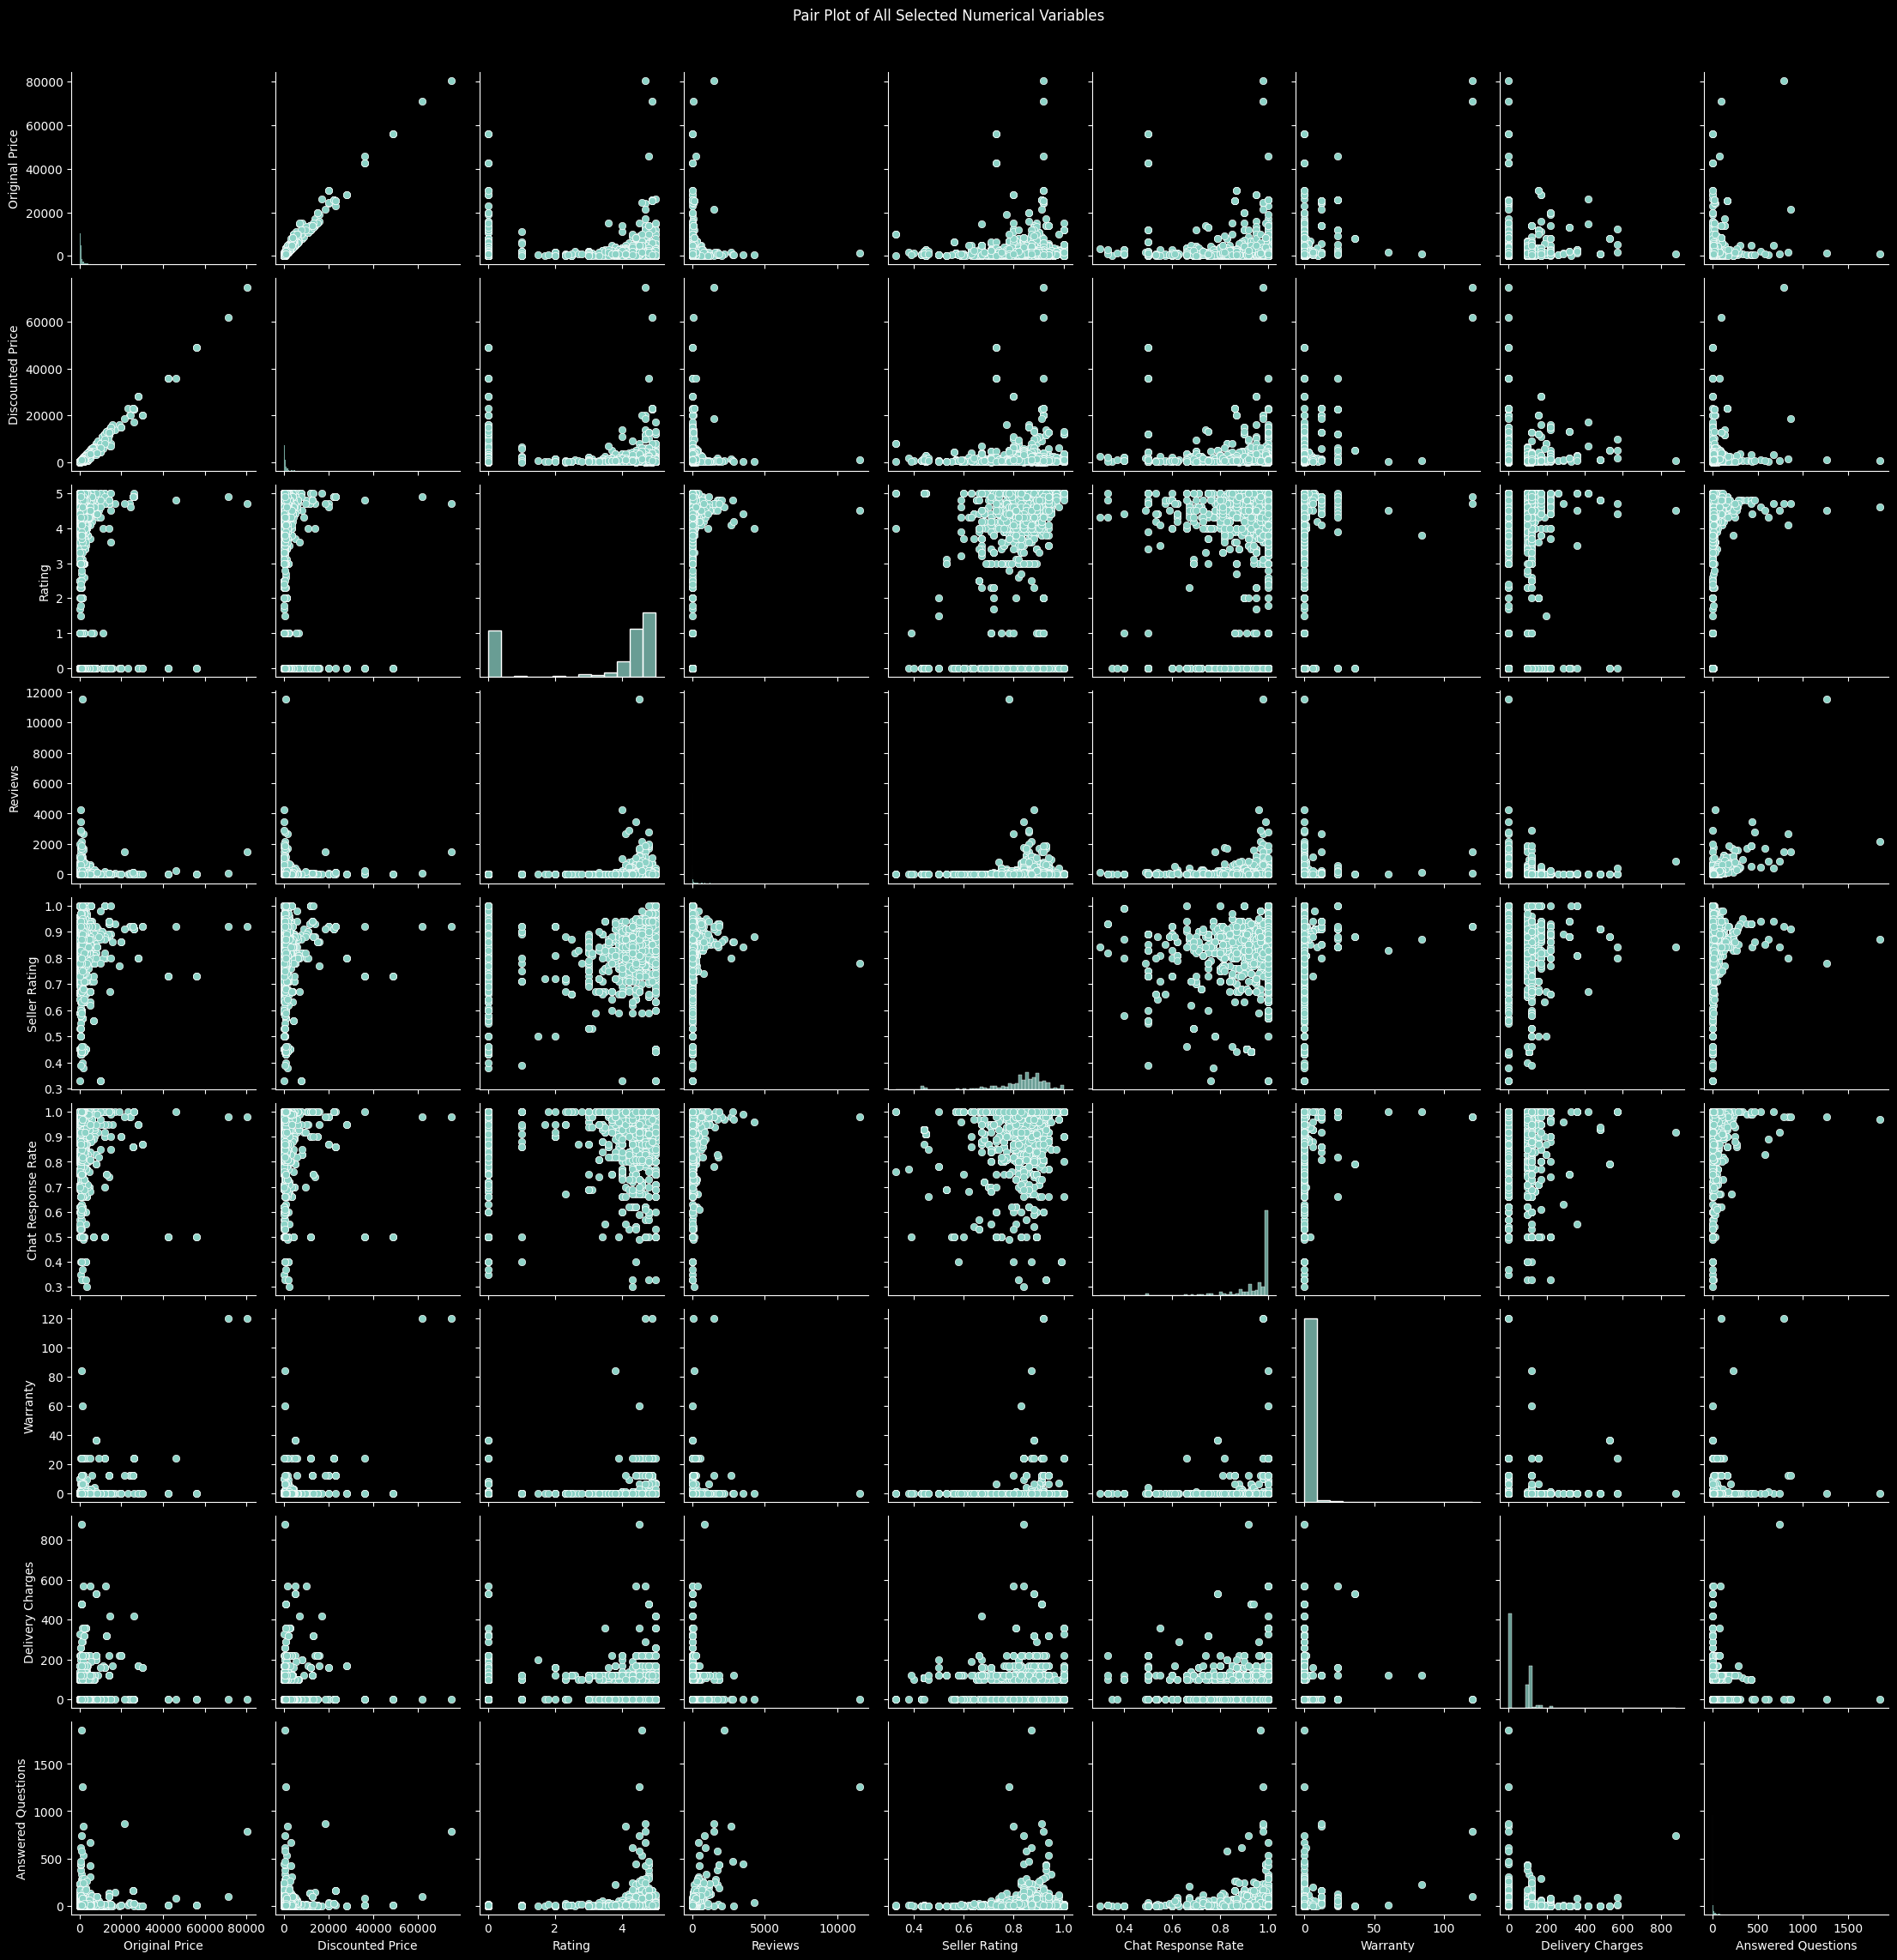

In [47]:
numerical_vars = ['Original Price', 'Discounted Price', 'Rating', 'Reviews', 
                  'Seller Rating', 'Chat Response Rate', 'Warranty', 
                  'Delivery Charges', 'Answered Questions']

# Select the numerical data
numerical_data = data[numerical_vars]

# Create the pair plot
plt.figure(figsize=(12, 12))
sns.pairplot(numerical_data)
plt.suptitle('Pair Plot of All Selected Numerical Variables', y=1.02)  # Adjust title position
plt.show()


#### Correlation Heatmap

To get a better understanding of the relationships, we can make a heatmap of the correlation.

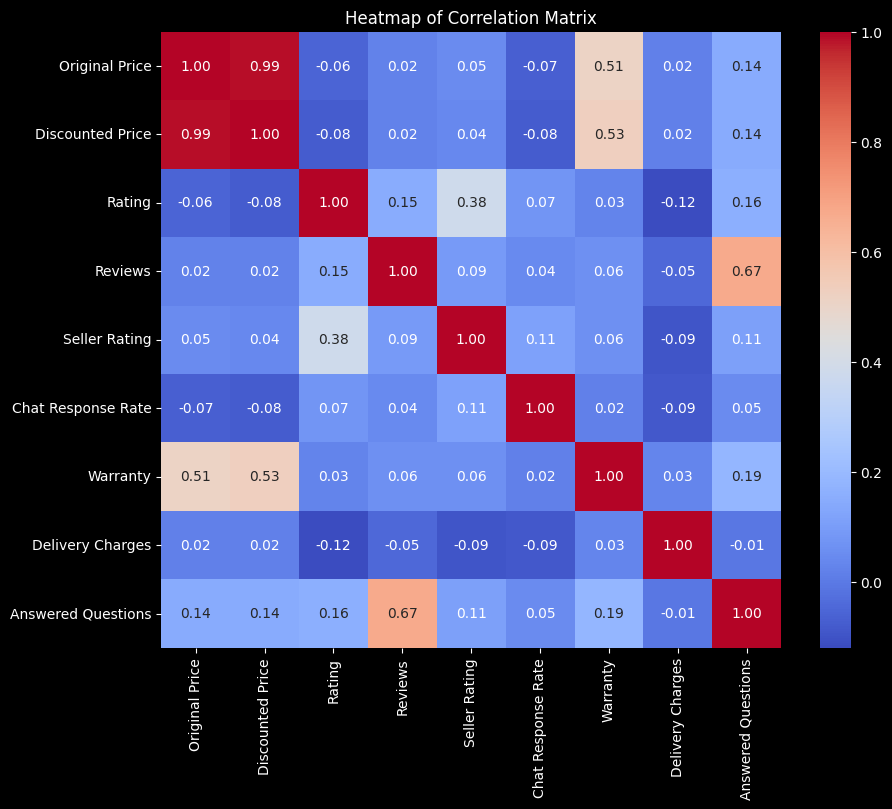

In [48]:
numerical_data = data[numerical_vars]

# Calculate the correlation matrix
corr_matrix = numerical_data.corr()

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Heatmap of Correlation Matrix')
plt.show()

We can see that the high correlations all seem to make sense, such as original price and discounted price. These two will obviously scale very closely together, especially considering they are more often that not, the same.

#### More than 2 Variables

Visualising how two variables are related to another variable with a 3D Scatter Plot

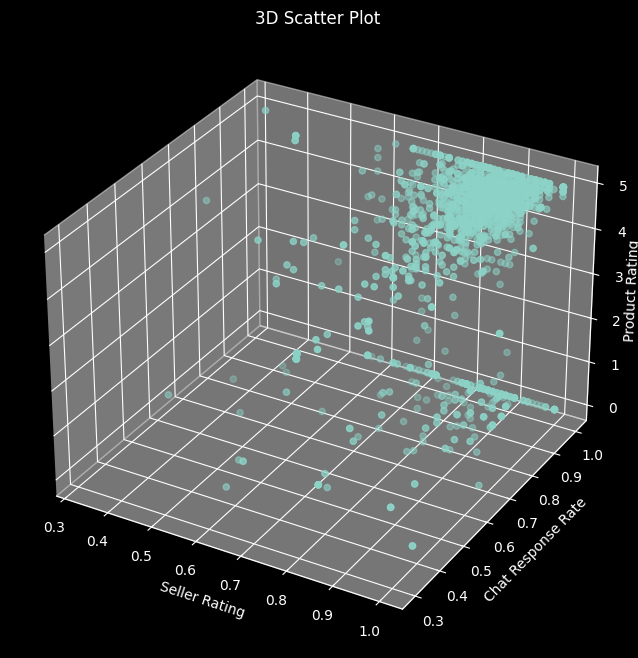

In [49]:
# 3D Scatter Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['Seller Rating'], df['Chat Response Rate'], df['Rating'])
ax.set_xlabel('Seller Rating')
ax.set_ylabel('Chat Response Rate')
ax.set_zlabel('Product Rating')
ax.zaxis.labelpad=-3
plt.title('3D Scatter Plot')
plt.show()

Next, we look at some bubble plots.

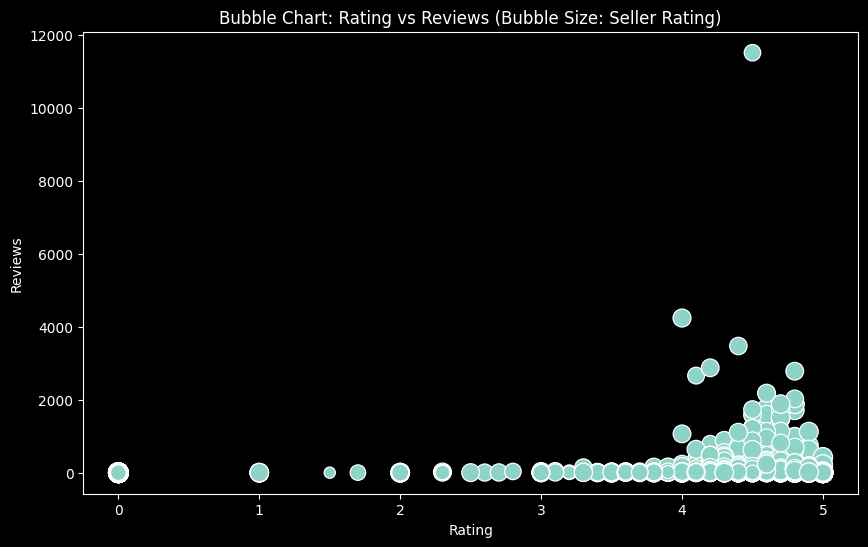

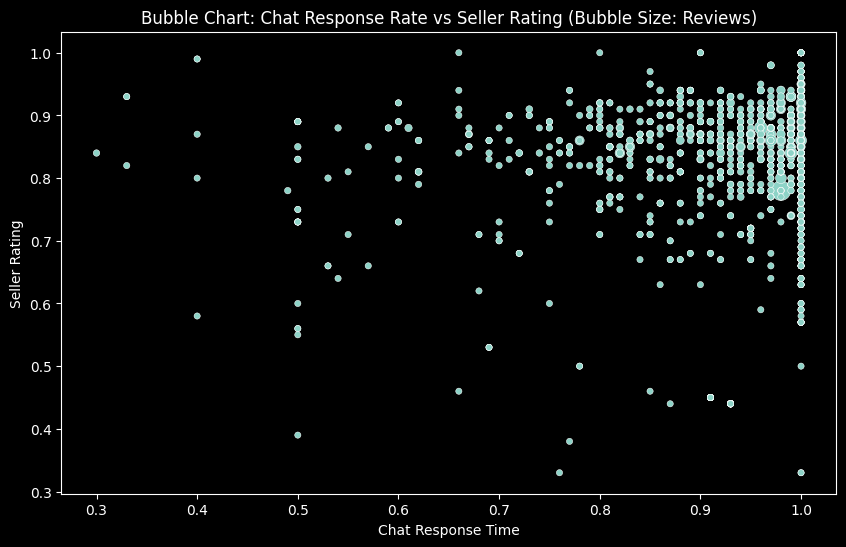

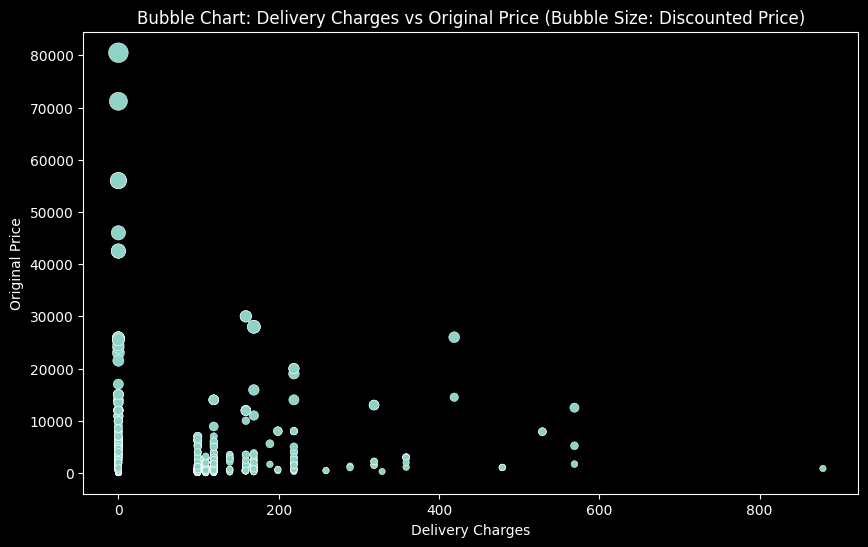

In [50]:
size_var = 'Reviews'

# Create the bubble chart
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Rating', y='Reviews', size='Seller Rating', legend=False, sizes=(20, 200))
plt.title('Bubble Chart: Rating vs Reviews (Bubble Size: Seller Rating)')
plt.xlabel('Rating')
plt.ylabel('Reviews')
plt.show()
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Chat Response Rate', y='Seller Rating', size='Reviews', legend=False, sizes=(20, 200))
plt.title('Bubble Chart: Chat Response Rate vs Seller Rating (Bubble Size: Reviews)')
plt.xlabel('Chat Response Time')
plt.ylabel('Seller Rating')
plt.show()
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Delivery Charges', y='Original Price', size='Discounted Price', legend=False, sizes=(20, 200))
plt.title('Bubble Chart: Delivery Charges vs Original Price (Bubble Size: Discounted Price)')
plt.xlabel('Delivery Charges')
plt.ylabel('Original Price')
plt.show()



... and some joint plots

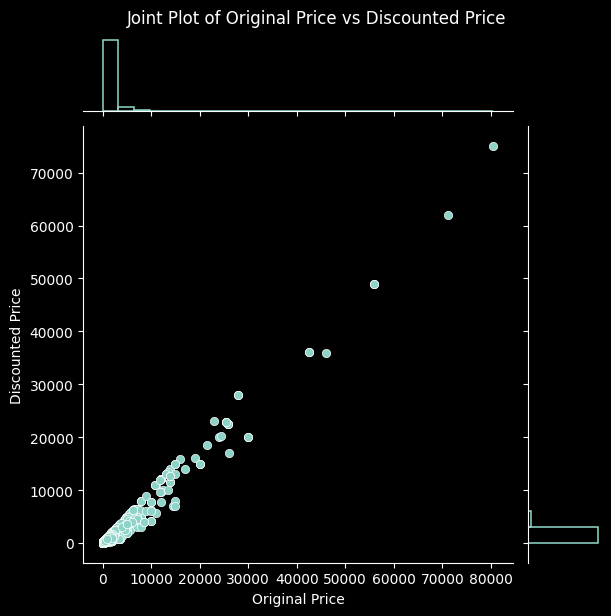

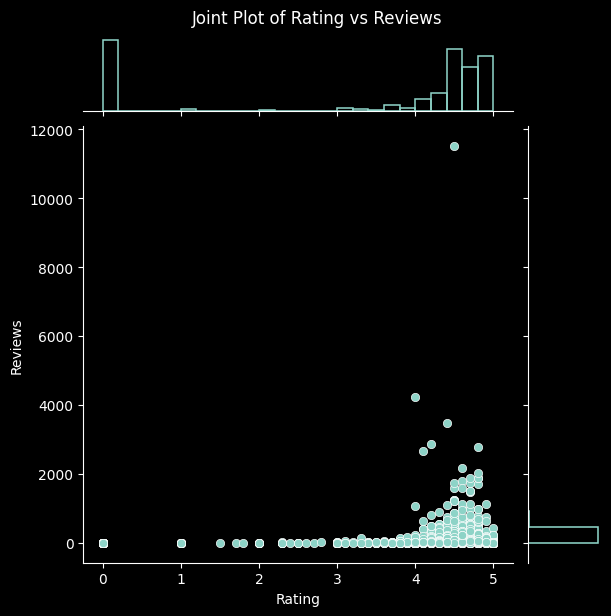

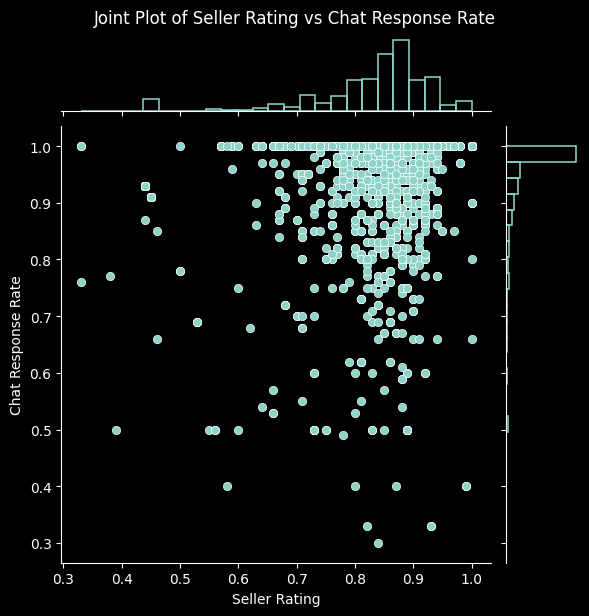

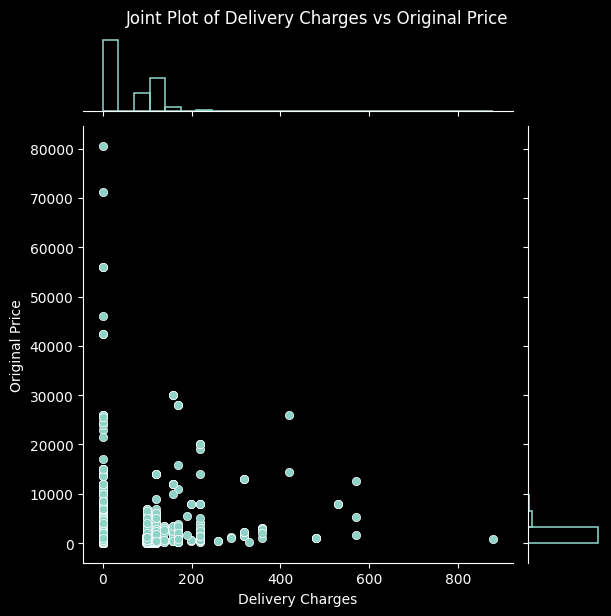

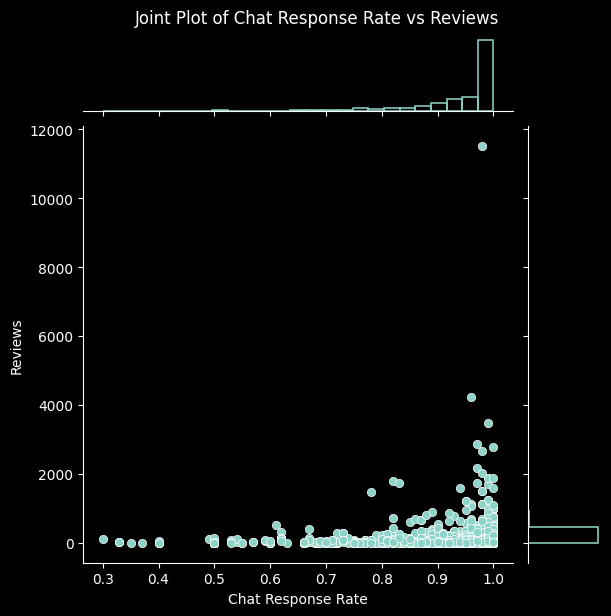

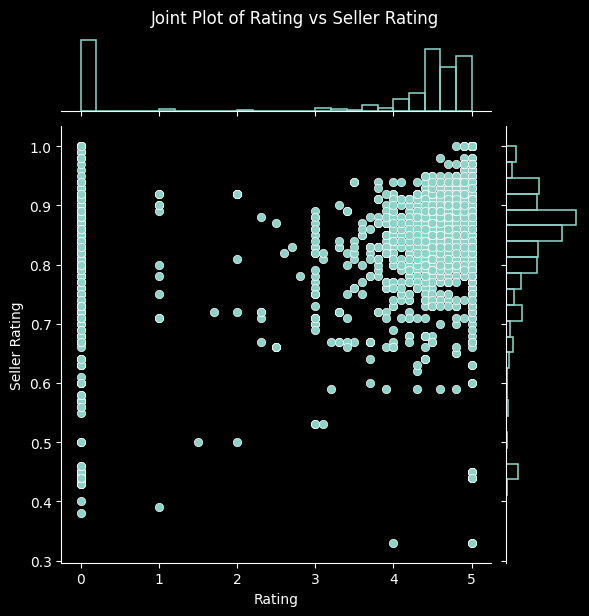

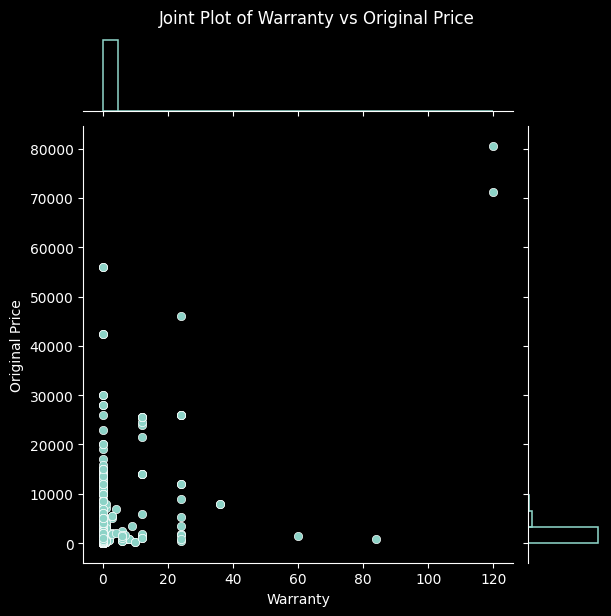

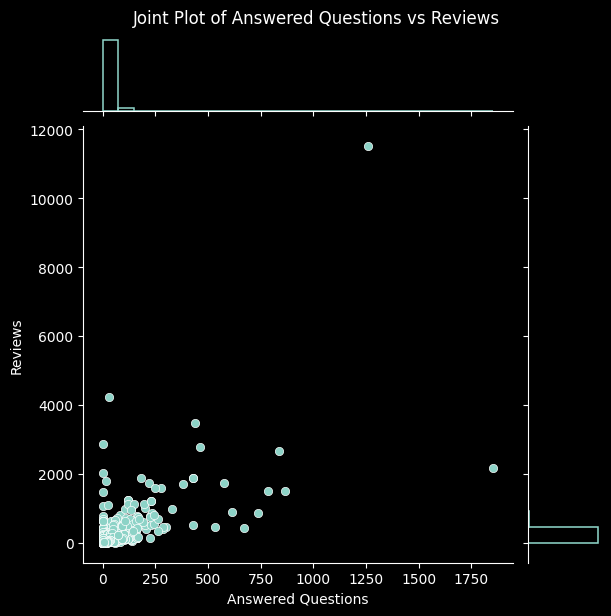

In [51]:
pairs = [
    ('Original Price', 'Discounted Price'),
    ('Rating', 'Reviews'),
    ('Seller Rating', 'Chat Response Rate')
]

# Create joint plots for each pair
for x_var, y_var in pairs:
    sns.jointplot(data=data, x=x_var, y=y_var, kind='scatter', marginal_kws=dict(bins=25, fill=False))
    plt.suptitle(f'Joint Plot of {x_var} vs {y_var}', y=1.02)
    plt.show()
additional_pairs = [
    ('Delivery Charges', 'Original Price'),
    ('Chat Response Rate', 'Reviews'),
    ('Rating', 'Seller Rating'),
    ('Warranty', 'Original Price'),
    ('Answered Questions', 'Reviews')
]

# Create joint plots for each additional pair
for x_var, y_var in additional_pairs:
    sns.jointplot(data=data, x=x_var, y=y_var, kind='scatter', marginal_kws=dict(bins=25, fill=False))
    plt.suptitle(f'Joint Plot of {x_var} vs {y_var}', y=1.02)
    plt.show()

Again, this process has led us to better understand the relationships among the columns in our dataset, along with verifying that they make sense. This gives us further reassurance that the data has been collected and processed correctly. With it thoroughly processed and analysed, we move on to our next steps.

## Section 3: Project Direction and Research Questions

After a thorough exploration of the data, we have decided to revisit our research questions and revise them to reflect
our deeper understanding of the data. We have come up with 2 research questions that seek to answer the general question of 'what differentiates products that perform from products that don't'.

Formally, these are our finalised research questions:

##### 1. What Feature Variables Should Sellers Optimise On Their Storefronts For Maximum Product Ratings?
##### 2. How Does Mistrust In Products Manifest In The Data? (and what can we do about it?)

We will use **machine learning** and **statistical analysis** to answer these questions, and hopefully report on novel findings that fill in the gaps in our collective knowledge about what determines a well performing product on e-commerce marketplaces like Daraz.